# U-Net++ Ablation Study: Semantic Segmentation 성능 및 구조 분석

## 1. 실험 개요 및 데이터 준비 (Experimental Setup)

본 실험은 의료 및 자율주행 이미지 등 정밀한 영역 분할(Semantic Segmentation)이 요구되는 태스크에서 널리 쓰이는 **U-Net++** 아키텍처의 핵심 구성 요소를 검증하기 위한 Ablation Study입니다.

단순한 성능 비교를 넘어, 모델의 다중 스케일 지도(Deep Supervision) 기법과 복합 손실 함수(Hybrid Loss: BCE + Dice)가 모델의 학습 안정성, 객체 경계선 추출 능력, 그리고 최악 조건에서의 강건성(Robustness)에 미치는 영향을 객관적이고 다각적으로 분석하고자 합니다.

데이터셋은 자율주행 도로 영역을 분할하는 KITTI Dataset을 사용하였으며, 모든 이미지는 $224 \times 224$ 해상도로 전처리되었습니다.

In [31]:
#필요한 라이브러리를 로드합니다.
import os
import math
import numpy as np
import torch
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from glob import glob

import torch.nn as nn
import torch.optim as optim

print('=3')

=3


## 2. 공정성 및 재현성 검증 (Reproducibility)

Ablation Study의 공정성을 확보하기 위해 모든 실험 환경(Random Seed, 하드웨어 설정 등)을 동일하게 통제하였습니다. 모델 간 성능 비교의 신뢰성을 확보하기 위한 핵심 단계입니다.

#### 2.1 주요 통제 변인
*   **고정 시드**: 42 (Random, Numpy, PyTorch 통합 고정)
*   **옵티마이저**: Adam (학습률 1e-4 고정)
*   **전처리 및 증강**: 224x224 해상도, Albumentations (HorizontalFlip, RandomSizedCrop 동등 적용)


In [32]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    # 1. 기본 random 시드 고정
    random.seed(seed)
    
    # 2. OS 환경 변수 고정 (시스템 해시 함수 고정)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Numpy 시드 고정 (Albumentations 등에서 사용)
    np.random.seed(seed)
    
    # 4. PyTorch 시드 고정 (CPU 및 GPU 가중치 초기화 고정)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 사용 시 필수
    
    # 5. Albumentations 전용 시드 고정 (이미지 증강 결정론적 모드)
    try:
        import albumentations as A
        # Albumentations 버전마다 방식이 다를 수 있어 두 가지 모두 시도합니다.
        # 최신 버전은 np.random을 따라가기도 하지만, 명시적으로 고정하는 것이 안전합니다.
    except ImportError:
        pass
        
    # 6. Cudnn(GPU 연산 라이브러리) 결정론적 모드 설정
    # 속도는 조금 느려지지만, 연산 순서를 고정하여 결과의 재현성을 확보합니다.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 7. 최신 PyTorch용 완전 결정론적 알고리즘 강제 설정
    # 일부 연산(Upsampling 등)에서 비결정론적 알고리즘 사용을 금지합니다.
    # 만약 특정 연산에서 에러가 발생한다면 이 부분만 주석 처리하세요.
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        # 구버전 파이토치 대응
        pass

# 실행! (커널을 재시작한 후 가장 먼저 실행하세요)
set_seed(42)


In [33]:
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

def build_augmentation(is_train=True):
  if is_train:    # 훈련용 데이터일 경우
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        min_max_height=(300, 370),
                        w2h_ratio=370/1242,
                        height=224,
                        width=224,
                        size=(224, 224),
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        width=224,
                        height=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행합니다.
                Resize(
                    width=224,
                    height=224
                    )
                ])

In [34]:
data_dir = os.path.join("data", "training")

from torch.utils.data import Dataset

class KittiDataset(Dataset):
    '''
    KittiDataset은 PyTorch의 Dataset을 상속받습니다.
    우리가 KittiDataset을 원하는 방식으로 preprocess하기 위해서 Dataset을 커스텀하여 사용합니다.
    '''
    def __init__(self,
                 dir_path,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 is_train=True,
                 augmentation=None):
        '''
        dir_path: dataset의 directory path입니다.
        img_size: preprocess에 사용할 입력이미지의 크기입니다.
        output_size: ground_truth를 만들어주기 위한 크기입니다.
        is_train: 이 Dataset이 학습용인지 테스트용인지 구분합니다.
        augmentation: 적용하길 원하는 augmentation 함수를 인자로 받습니다.
        '''
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size

        # load_dataset()을 통해 kitti dataset의 경로에서 라벨과 이미지를 확인합니다.
        self.data = self.load_dataset()

    def load_dataset(self):
        # kitti dataset에서 필요한 정보(이미지 경로 및 라벨)를 directory에서 확인하고 로드하는 함수입니다.
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))

        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))

        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        # Dataset의 length로서 전체 dataset 크기를 반환합니다.
        return len(self.data)

    def __getitem__(self, index):
        # 입력과 출력을 만듭니다.
        # 입력은 resize 및 augmentation이 적용된 input image이고
        # 출력은 semantic label입니다.
        input_img_path, output_path = self.data[index]

        _input = imread(input_img_path)
        _output = imread(output_path)

        # 특정 라벨을 이진 마스크로 변환
        _output = (_output == 7).astype(np.uint8) * 1

        data = {
            "image": _input,
            "mask": _output,
        }

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0  # Normalize
            _output = augmented["mask"]

        # 📌 target 차원 확장 (H, W) → (1, H, W)
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1),  # (H, W, C) → (C, H, W)
            torch.tensor(_output, dtype=torch.float32)  # (1, H, W) 형식 유지
        )

    def shuffle_data(self):
        # 한 epoch가 끝나면 실행되는 함수입니다. 학습 중인 경우에 데이터를 random shuffle합니다.
        if self.is_train:
            np.random.shuffle(self.data)

In [35]:
from torch.utils.data import DataLoader

# Augmentation 설정
augmentation = build_augmentation()
test_preproc = build_augmentation(is_train=False)

train_dataset = KittiDataset(
    data_dir,
    augmentation=augmentation,
    is_train=True
)

test_dataset = KittiDataset(
    data_dir,
    augmentation=test_preproc,
    is_train=False
)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19784\2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


## 3. 모델 설계 및 평가 지표 (Architecture & Metrics)

U-Net++의 아키텍처적 우수성을 단계별로 검증하기 위해, 기본 베이스라인 모델 3종과 아블레이션 스터디용 모델 4종을 차례대로 설계하였습니다.

#### 3.1 대조군 설계
1. **`UNet_Baseline`**: 가장 기본적인 U-Net 구조.




In [36]:
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)

        # Expanding Path (Decoder)
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512, 256)
        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256, 128)
        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """2개의 Conv Layer로 이루어진 블록"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)
        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.bottleneck(p4)
        c5 = self.dropout(c5)

        # Decoder
        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.dec6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.dec7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.dec8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.dec9(u9)

        # Output
        output = torch.sigmoid(self.final(c9))
        return output

2. **`UNet_BN`**: Batch Normalization의 효과 검증용.


In [37]:
import torch.nn as nn
import torch.nn.functional as F

class UNet_BN(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet_BN, self).__init__()

        # Contracting Path (Encoder)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)

        # Expanding Path (Decoder)
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512, 256)
        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256, 128)
        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """
        2개의 (Conv -> BatchNorm -> ReLU) Layer로 이루어진 블록
        배치 정규화를 사용할 때는 Conv의 bias를 False로 설정하는 것이 정석입니다.
        """
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), # 첫 번째 컨볼루션 후 배치놈
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), # 두 번째 컨볼루션 후 배치놈
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)
        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.bottleneck(p4)
        c5 = self.dropout(c5)

        # Decoder
        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.dec6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.dec7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.dec8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.dec9(u9)

        # Output (Binary Segmentation을 위해 시그모이드 적용)
        output = torch.sigmoid(self.final(c9))
        return output


3. **`UNet_BN_Bilinear`**: **[최종 대조군]** U-Net++와 동일한 업샘플링 방식(Bilinear)을 채택하여 '네트워크 구조의 차이'만을 남긴 엄격한 통제 모델.

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet_BN_Bilinear(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet_BN_Bilinear, self).__init__()

        # --- 1. Encoder (Contracting Path) ---
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # --- 2. Bottleneck ---
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)

        # --- 3. Upsampling Layer (Bilinear) ---
        # 가중치 없이 수학적으로 크기만 2배로 키우는 레이어입니다.
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # --- 4. Decoder (Expanding Path) ---
        # Upsample은 채널을 줄이지 않으므로, DoubleConv가 받는 채널 수(in_channels)를 수정함
        self.dec6 = self.double_conv(1024 + 512, 512) # 1024(up) + 512(c4)
        self.dec7 = self.double_conv(512 + 256, 256)  # 512(up) + 256(c3)
        self.dec8 = self.double_conv(256 + 128, 128)  # 256(up) + 128(c2)
        self.dec9 = self.double_conv(128 + 64, 64)    # 128(up) + 64(c1)

        # --- 5. Output Layer ---
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)
        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.bottleneck(p4)
        c5 = self.dropout(c5)

        # Decoder (Bilinear Upsampling 적용)
        u6 = self.up(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.dec6(u6)

        u7 = self.up(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.dec7(u7)

    
        u8 = self.up(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.dec8(u8)

        u9 = self.up(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.dec9(u9)

        # Output
        output = torch.sigmoid(self.final(c9))
        return output


#### 3.2 실험군 설계 (U-Net++ Ablation)
다중 스케일 지도(Deep Supervision)의 On/Off 및 손실 함수(BCE vs Hybrid)의 조합에 따라 4가지 Case(A, B, C, D)로 분류하여 실험을 진행합니다.

In [39]:
import torch
import torch.nn as nn

class VGGBlock(nn.Module):
    """U-Net++의 기본 단위가 되는 Double Conv 블록 (BN 포함)"""
    def __init__(self, in_channels, middle_channels, out_channels):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, middle_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(middle_channels)
        self.conv2 = nn.Conv2d(middle_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        return out

class UNetPlusPlus(nn.Module):
    def __init__(self, input_channels=3, output_channels=1, deep_supervision=False):
        super().__init__()
        self.deep_supervision = deep_supervision
        nb_filter = [64, 128, 256, 512, 1024] # 각 층의 채널 수

        # --- Upsampling 레이어 정의 ---
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # --- Nested Blocks (X_i,j) 정의 ---
        # j=0: Encoder (기존 U-Net의 Downward Path)
        self.X_0_0 = VGGBlock(input_channels, nb_filter[0], nb_filter[0])
        self.X_1_0 = VGGBlock(nb_filter[0], nb_filter[1], nb_filter[1])
        self.X_2_0 = VGGBlock(nb_filter[1], nb_filter[2], nb_filter[2])
        self.X_3_0 = VGGBlock(nb_filter[2], nb_filter[3], nb_filter[3])
        self.X_4_0 = VGGBlock(nb_filter[3], nb_filter[4], nb_filter[4])

        # j=1: 1단계 Nested Skip (기존 U-Net의 Skip Connection 위치)
        self.X_0_1 = VGGBlock(nb_filter[0] + nb_filter[1], nb_filter[0], nb_filter[0])
        self.X_1_1 = VGGBlock(nb_filter[1] + nb_filter[2], nb_filter[1], nb_filter[1])
        self.X_2_1 = VGGBlock(nb_filter[2] + nb_filter[3], nb_filter[2], nb_filter[2])
        self.X_3_1 = VGGBlock(nb_filter[3] + nb_filter[4], nb_filter[3], nb_filter[3])

        # j=2: 2단계 Dense Skip
        self.X_0_2 = VGGBlock(nb_filter[0]*2 + nb_filter[1], nb_filter[0], nb_filter[0])
        self.X_1_2 = VGGBlock(nb_filter[1]*2 + nb_filter[2], nb_filter[1], nb_filter[1])
        self.X_2_2 = VGGBlock(nb_filter[2]*2 + nb_filter[3], nb_filter[2], nb_filter[2])

        # j=3: 3단계 Dense Skip
        self.X_0_3 = VGGBlock(nb_filter[0]*3 + nb_filter[1], nb_filter[0], nb_filter[0])
        self.X_1_3 = VGGBlock(nb_filter[1]*3 + nb_filter[2], nb_filter[1], nb_filter[1])

        # j=4: 최종 Decoder (j=4)
        self.X_0_4 = VGGBlock(nb_filter[0]*4 + nb_filter[1], nb_filter[0], nb_filter[0])

        # --- Output Layers ---
        if self.deep_supervision:
            self.final1 = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)
            self.final2 = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)
            self.final3 = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)
            self.final4 = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)
        else:
            self.final = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # --- Column j=0 (Encoder) ---
        x0_0 = self.X_0_0(x)
        x1_0 = self.X_1_0(self.pool(x0_0))
        x2_0 = self.X_2_0(self.pool(x1_0))
        x3_0 = self.X_3_0(self.pool(x2_0))
        x4_0 = self.X_4_0(self.pool(x3_0))

        # --- Column j=1 ---
        x0_1 = self.X_0_1(torch.cat([x0_0, self.up(x1_0)], 1))
        x1_1 = self.X_1_1(torch.cat([x1_0, self.up(x2_0)], 1))
        x2_1 = self.X_2_1(torch.cat([x2_0, self.up(x3_0)], 1))
        x3_1 = self.X_3_1(torch.cat([x3_0, self.up(x4_0)], 1))

        # --- Column j=2 ---
        x0_2 = self.X_0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))
        x1_2 = self.X_1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        x2_2 = self.X_2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))

        # --- Column j=3 ---
        x0_3 = self.X_0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))
        x1_3 = self.X_1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))

        # --- Column j=4 ---
        x0_4 = self.X_0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))

        # --- Output (Sigmoid 포함) ---
        if self.deep_supervision:
            out1 = torch.sigmoid(self.final1(x0_1))
            out2 = torch.sigmoid(self.final2(x0_2))
            out3 = torch.sigmoid(self.final3(x0_3))
            out4 = torch.sigmoid(self.final4(x0_4))
            return [out1, out2, out3, out4]
        else:
            out = torch.sigmoid(self.final(x0_4))
            return out


#### 3.3 실시간 학습 모니터링을 위한 평가지표 정의
학습 과정에서 모델의 수렴 상태를 직관적으로 파악하기 위해 mIoU(Mean Intersection over Union) 계산 함수를 정의합니다. 

**주의**: 본 함수는 학습 루프 내에서 배치(Batch) 단위로 빠르게 계산되어 **실시간 모니터링 및 모델 저장(Best 체크포인트)용**으로 활용됩니다. 테스트 셋 전체에 대한 최종 정밀 분석 데이터는 추후 별도의 전수 조사 루프를 통해 산출합니다.


In [40]:
def calculate_miou(outputs, targets, threshold=0.5):
    """
    파이토치 텐서 기반의 mIoU 계산 함수 (Binary Segmentation용)
    - outputs: 모델의 예측값 (Batch, 1, H, W)
    - targets: 실제 정답값 (Batch, 1, H, W)
    """
    with torch.no_grad():
        # 1. 시그모이드 통과된 확률값을 이진 마스크(0 or 1)로 변환
        preds = (outputs > threshold).float()
        targets = targets.float()

        # 2. 교집합과 합집합 계산 (Batch 차원 제외하고 전체 합산)
        intersection = (preds * targets).sum(dim=(1, 2, 3))
        union = (preds + targets).clamp(0, 1).sum(dim=(1, 2, 3))

        # 3. 이미지별 IoU 계산 (합집합이 0인 경우 1로 처리하여 에러 방지)
        iou = (intersection + 1e-7) / (union + 1e-7)
        
        # 4. 배치 전체의 평균 IoU 반환
        return iou.mean().item()


#### 3.4 복합 손실 함수 설계 (Hybrid Loss)
단일 손실 함수의 한계를 극복하고 분할 정밀도를 높이기 위해 BCE(Binary Cross Entropy)와 Dice Loss를 결합한 Hybrid Loss를 설계합니다.

*   **BCE Loss**: 각 픽셀 단위의 분류 정확도를 최적화하여 지역적인 특징을 학습합니다.
*   **Dice Loss**: 예측 영역과 정답 영역의 전체적인 겹침(Overlap) 정도를 최적화하여, 객체의 형태 및 경계선(Boundary) 추출 능력을 보완합니다.
*   본 실험에서는 두 손실 함수를 1:1 비율로 가중 합산하여 학습에 적용합니다.


In [41]:
class HybridLoss(nn.Module):
    """BCE(지역적 픽셀 손실) + Dice(영역적 겹침 손실) 통합 클래스"""
    def __init__(self, weight_bce=0.5, weight_dice=0.5):
        super().__init__()
        self.bce = nn.BCELoss()
        self.weight_bce = weight_bce
        self.weight_dice = weight_dice

    def forward(self, inputs, targets):
        # 1. BCE Loss
        bce_loss = self.bce(inputs, targets)
        
        # 2. Dice Loss
        smooth = 1e-7
        if inputs.dim() > 2:
            inputs = inputs.view(inputs.size(0), -1)
            targets = targets.view(targets.size(0), -1)
        
        intersection = (inputs * targets).sum(1)
        dice = (2. * intersection + smooth) / (inputs.sum(1) + targets.sum(1) + smooth)
        dice_loss = 1 - dice.mean()
        
        # 3. 통합 (가중치 적용)
        return (self.weight_bce * bce_loss) + (self.weight_dice * dice_loss)


## 4. 모델 학습 수행 (Model Training)

공정한 비교를 위해 모든 모델에 동일한 학습 루프(`run_experiment`)를 적용합니다.

*   **통합 실험 파이프라인**: `run_experiment` 함수는 Deep Supervision의 유무에 따른 로스 계산 방식의 변화와 다양한 손실 함수(BCE, Hybrid)의 교체를 자동으로 처리하도록 설계되었습니다. 이를 통해 베이스라인 3종과 아블레이션 케이스 4종(Case A~D)을 하나의 통일된 로직 내에서 실험하여 휴먼 에러를 방지하고 실험의 일관성을 확보하였습니다.
*   **배치 누적 (Gradient Accumulation)**: 실질 배치 사이즈를 16으로 모사(Batch 4, Accumulation 4)하여 제한된 VRAM 환경에서도 안정적인 학습 궤적을 확보하였습니다.
*   **조기 종료 (Early Stopping)**: 과적합 방지를 위해 Validation Loss 기준으로 Patience 20을 적용하였으며, 모델 저장은 Validation mIoU가 최고점일 때 수행하여 실제 평가 지표와의 논리적 일관성을 유지하였습니다.
*   **실험 데이터 관리**: 각 실험의 결과물은 `models/` 디렉토리에 모델명별로 자동 저장됩니다. 최고 성능의 가중치는 `{model_name}.pt` 파일로, 에폭별 학습 로그(Loss, mIoU)는 `{model_name}_history.csv` 파일로 기록되어 사후 분석의 객관성을 보장합니다.


In [42]:
import pandas as pd
import os
from tqdm.auto import tqdm

def run_experiment(create_model_fn, model_name, criterion=None, lr=1e-4, num_epochs=100, patience=20):
    """
    U-Net++ 아블레이션 스터디 통합 학습 함수
    - criterion: 별도로 전달하지 않으면 기본적으로 nn.BCELoss()를 사용합니다.
    """
    # 1. 설정 및 준비
    set_seed(42) 
    model = create_model_fn()
    
    # 만약 criterion을 따로 안 넣어줬다면 기본 BCE 사용
    if criterion is None:
        criterion = nn.BCELoss()
        
    model_dir = "models"
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, f"{model_name}.pt") 
    csv_path = os.path.join(model_dir, f"{model_name}_history.csv")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    accum_steps = 4 
    history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_miou': []}
    counter = 0
    best_val_loss = float('inf') 
    best_val_miou = 0.0          

    epoch_pbar = tqdm(range(num_epochs), desc=f"Experiment: {model_name}")

    for epoch in epoch_pbar:
        # --- [Train Phase] ---
        model.train()
        running_train_loss = 0.0
        optimizer.zero_grad()
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]", leave=False)
        for i, (inputs, targets) in enumerate(train_pbar):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            # 🌟 [Ablation Logic] Deep Supervision 처리 (outputs가 리스트인 경우)
            if isinstance(outputs, list):
                # 모든 중간 출력물들의 로스를 계산하여 평균냄
                loss = sum([criterion(out, targets.float()) for out in outputs]) / len(outputs)
            else:
                loss = criterion(outputs, targets.float())
                
            loss = loss / accum_steps
            loss.backward()
            
            if (i + 1) % accum_steps == 0:
                optimizer.step()
                optimizer.zero_grad()
                
            running_train_loss += loss.item() * accum_steps
            train_pbar.set_postfix(loss=f"{(loss.item() * accum_steps):.4f}")
        
        avg_train_loss = running_train_loss / len(train_loader)
        
        # --- [Validation Phase] ---
        model.eval()
        running_val_loss = 0.0
        running_val_miou = 0.0
        val_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1} [Val]", leave=False)
        
        with torch.no_grad():
            for inputs, targets in val_pbar:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                
                # 🌟 [Ablation Logic] 검증 시 mIoU는 항상 '마지막 출력'으로만 계산
                if isinstance(outputs, list):
                    v_loss = sum([criterion(out, targets.float()) for out in outputs]) / len(outputs)
                    final_output = outputs[-1] # 가장 정교한 마지막 레이어 결과
                else:
                    v_loss = criterion(outputs, targets.float())
                    final_output = outputs
                
                running_val_loss += v_loss.item()
                v_miou = calculate_miou(final_output, targets) # 최종 결과물로 mIoU 계산
                running_val_miou += v_miou
                val_pbar.set_postfix(loss=f"{v_loss.item():.4f}", miou=f"{v_miou:.4f}")
                
        avg_val_loss = running_val_loss / len(test_loader)
        avg_val_miou = running_val_miou / len(test_loader)
        
        # 히스토리 저장 및 출력
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_miou'].append(avg_val_miou)
        
        epoch_pbar.set_postfix(val_L=f"{avg_val_loss:.3f}", val_mIoU=f"{avg_val_miou:.3f}")
        tqdm.write(f"[{model_name}] Epoch {epoch+1:3d} | Train L: {avg_train_loss:.4f} | Val L: {avg_val_loss:.4f} | Val mIoU: {avg_val_miou:.4f}")
        
        # 🌟 New Best mIoU! Model Saved.
        if avg_val_miou > best_val_miou:
            best_val_miou = avg_val_miou
            torch.save(model.state_dict(), model_path)
            tqdm.write(f"  --> 🌟 New Best mIoU! Saved: {best_val_miou:.4f}")

        # Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                tqdm.write(f"🛑 Early Stopping at Epoch {epoch+1}.")
                break

    pd.DataFrame(history).to_csv(csv_path, index=False)
    print(f"✅ Experiment Finished. History saved to {csv_path}")
    return best_val_miou


### 4.1 단계별 실험 수행 (Step-by-Step Experiments)

본격적인 아블레이션 스터디에 앞서 성능 향상의 근거를 명확히 하기 위해 베이스라인부터 최종 모델까지 총 7단계의 실험을 순차적으로 수행합니다. 모든 실험은 앞서 정의한 고정 시드와 동일한 하이퍼파라미터 조건 하에 실행됩니다.

#### [Step 1] 베이스라인 및 대조군 형성
*   **UNet_Baseline**: 최소한의 구조를 가진 기본 모델입니다.
*   **UNet_with_BatchNorm**: 학습 안정화 및 성능 향상을 위한 BN의 기여도를 확인합니다.
*   **UNet_BN_Bilinear**: U-Net++와 동일한 업샘플링 조건을 적용하여, 구조적 차이만을 비교하기 위한 최종 대조군 역할을 합니다.

#### [Step 2] U-Net++ 아블레이션 스터디 (Case A~D)
U-Net++의 핵심 기능을 조합하여 구조적 이점과 학습 전략의 시너지를 검증합니다.
*   **Case A (UPP_A)**: Nested Skip Connection의 순수 성능 향상 폭을 확인합니다.
*   **Case B (UPP_B)**: Hybrid Loss 도입에 따른 영역 분할 정밀도 변화를 관찰합니다.
*   **Case C (UPP_C)**: Deep Supervision 적용 시 다중 스케일 특징 추출의 효과를 분석합니다.
*   **Case D (UPP_D)**: 아키텍처 개선과 학습 최적화가 결합된 최종 성능을 확인합니다.


In [ ]:
# --- Baseline U-Net 학습 실행 ---
# 모든 설정(시드 42, 배축 누적 16, 페이션스 20)이 자동으로 적용됩니다.

run_experiment(
    create_model_fn=lambda: UNet(input_channels=3, output_channels=1),
    model_name="UNet_Baseline",
    lr=1e-4,
    num_epochs=100,
    patience=20
)


In [ ]:
# 일반 U-Net + 배치 정규화(BN) 실험 시작!
run_experiment(lambda: UNet_BN(), "UNet_with_BatchNorm", lr=1e-4)

In [ ]:
# --- [실험] UNet_BN + Bilinear Upsampling ---
# U-Net++와 모든 조건을 일치시킨 최종 베이스라인입니다.

run_experiment(
    create_model_fn=lambda: UNet_BN_Bilinear(),
    model_name="UNet_BN_Bilinear",
    lr=1e-4,
    num_epochs=100,
    patience=20
)

In [ ]:
run_experiment(lambda: UNetPlusPlus(deep_supervision=False), "UPP_A_Off_BCE")


In [ ]:
run_experiment(lambda: UNetPlusPlus(deep_supervision=False), "UPP_B_Off_Hybrid", criterion=HybridLoss())


In [ ]:
run_experiment(lambda: UNetPlusPlus(deep_supervision=True), "UPP_C_On_BCE")


In [ ]:
run_experiment(lambda: UNetPlusPlus(deep_supervision=True), "UPP_D_On_Hybrid", criterion=HybridLoss())


## 5. 정량적 성능 분석 (Quantitative Analysis)

앞서 학습한 7가지 모델의 로그 및 결과를 로드하여 성능 우열과 구조적 이점을 분석합니다. 성능 평가는 클래스 불균형에 강건한 **mIoU (Mean Intersection over Union)** 지표를 최종 기준으로 삼습니다.

### 5.0 평가 데이터 로드 및 전수 추론 (Data Loading & Inference)

본격적인 비교 시각화에 앞서, 개별적으로 저장된 7개 모델의 학습 결과물을 한 번에 메모리에 로드하여 분석 환경을 세팅합니다.

1.  **학습 로그 로드**: 각 모델별로 저장된 `history.csv` 파일(Train/Val Loss, Val mIoU)을 Pandas DataFrame으로 일괄 로드하여 `histories` 딕셔너리에 저장합니다.
2.  **최종 가중치 기반 전수 추론**: 최고 성능을 기록한 가중치(`.pt`)를 차례대로 불러와 테스트 셋 30장에 대한 추론을 진행합니다.
3.  **데이터 사전 확보**: `get_individual_ious` 함수를 통해 총 210개(7개 모델 $\times$ 30장)의 개별 IoU 데이터를 계산하고 `results` 딕셔너리에 저장합니다.

이와 같이 평가에 필요한 모든 수치 데이터를 메모리에 사전 확보함으로써, 이후 진행될 다각적인 비교 시각화(추세선, 바 차트, 산점도 등)를 빠르고 유연하게 수행할 수 있습니다.


In [43]:
import os
import pandas as pd

# 1. 불러올 모델 이름들 (확장자 제외)
model_names = [
    "UNet_Baseline", # 100에포크짜리로 교체!
    "UNet_with_BatchNorm",
    "UNet_BN_Bilinear",
    "UPP_A_Off_BCE",
    "UPP_B_Off_Hybrid",
    "UPP_C_On_BCE",
    "UPP_D_On_Hybrid"
]

model_dir = "models"

# 2. 데이터를 담을 딕셔너리 생성
# histories: CSV 데이터를 Pandas DataFrame으로 저장
# weights: .pt 파일의 경로를 저장
histories = {}
weights = {}

# 3. 자동 로드 루프
print("📥 실험 결과 자동 로드 시작...\n")
for name in model_names:
    csv_path = os.path.join(model_dir, f"{name}_history.csv")
    pt_path = os.path.join(model_dir, f"{name}.pt")
    
    # CSV 파일이 존재하면 읽어서 저장
    if os.path.exists(csv_path):
        histories[name] = pd.read_csv(csv_path)
        print(f"✅ [CSV 로드 완료] {name} (총 {len(histories[name])} 에포크)")
    else:
        print(f"❌ [CSV 없음] {csv_path} 파일을 찾을 수 없습니다.")
        
    # PT 파일 경로 저장 (당장 메모리에 올리면 무거우니 경로만 저장)
    if os.path.exists(pt_path):
        weights[name] = pt_path
    else:
        # 100에포크짜리 베이스라인 pt 이름이 다를 수 있으니 유연하게 처리
        print(f"⚠️ [PT 없음] {pt_path} 파일이 없습니다. (확인 필요)")

print("\n🎉 모든 데이터 로드 완료!")


📥 실험 결과 자동 로드 시작...

✅ [CSV 로드 완료] UNet_Baseline (총 41 에포크)
✅ [CSV 로드 완료] UNet_with_BatchNorm (총 100 에포크)
✅ [CSV 로드 완료] UNet_BN_Bilinear (총 100 에포크)
✅ [CSV 로드 완료] UPP_A_Off_BCE (총 93 에포크)
✅ [CSV 로드 완료] UPP_B_Off_Hybrid (총 100 에포크)
✅ [CSV 로드 완료] UPP_C_On_BCE (총 100 에포크)
✅ [CSV 로드 완료] UPP_D_On_Hybrid (총 100 에포크)

🎉 모든 데이터 로드 완료!


### 5.0.1 정밀 분석용 개별 IoU 추출 (Individual IoU Calculation)

앞서 정의한 학습 루프 내의 `calculate_miou` 함수가 배치(Batch) 단위의 빠른 평균을 구하는 '모니터링 용도'였다면, 본 단계에서 정의하는 `get_individual_ious` 함수는 **테스트 셋 30장 각각에 대한 정확한 독립적 성능을 추출하기 위한 '최종 정밀 분석 용도'**입니다.

*   **배치 평균의 오류 배제**: 이미지를 뭉뚱그려 평균 내지 않고, 각각의 이미지(샘플) 단위로 교집합과 합집합을 엄격하게 계산합니다.
*   **분포 및 강건성 분석 기반**: 하나의 평균 점수(mIoU)로 가려질 수 있는 '극단적으로 어려운 샘플(최악의 케이스)'에 대한 모델의 대처 능력을 분석하기 위해, 30개의 파편화된 원시 데이터(Raw Score)를 훼손 없이 수집합니다.
*   **Deep Supervision 호환**: U-Net++의 다중 출력(List) 결과물을 자동으로 감지하여, 가장 정교한 마지막 레이어의 출력값만을 평가에 반영하도록 로직을 일원화하였습니다.


In [44]:
import torch
import numpy as np
import os

# 1. 개별 IoU를 계산하는 함수 (Deep Supervision 대응 업그레이드)
def get_individual_ious(model, loader, device):
    model.eval()
    all_ious = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            # 🌟 [중요] U-Net++ Deep Supervision 대응: 리스트가 반환되면 마지막(가장 정교한) 출력 사용
            if isinstance(outputs, list):
                final_output = outputs[-1]
            else:
                final_output = outputs
                
            # 이진화 (Threshold 0.5)
            preds = (final_output > 0.5).float()
            targets = targets.float()
            
            # 이미지별 IoU 계산
            intersection = (preds * targets).sum(dim=(1, 2, 3))
            union = (preds + targets).clamp(0, 1).sum(dim=(1, 2, 3))
            
            iou = (intersection + 1e-7) / (union + 1e-7)
            all_ious.extend(iou.cpu().numpy())
    return all_ious

# 2. 7개 모델 전체 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_model_configs = [
    # Baseline 그룹
    {"name": "UNet_Baseline", "class": UNet, "args": {}, "path": "models/UNet_Baseline.pt", "color": "#FF6B6B"},
    {"name": "UNet_BN", "class": UNet_BN, "args": {}, "path": "models/UNet_with_BatchNorm.pt", "color": "#FF9E7D"},
    {"name": "UNet_BN_Bilinear", "class": UNet_BN_Bilinear, "args": {}, "path": "models/UNet_BN_Bilinear.pt", "color": "#FFCC70"},
    
    # U-Net++ 그룹 (A, B, C, D)
    {"name": "UPP_A_Off_BCE", "class": UNetPlusPlus, "args": {"deep_supervision": False}, "path": "models/UPP_A_Off_BCE.pt", "color": "#8FD6E1"},
    {"name": "UPP_B_Off_Hybrid", "class": UNetPlusPlus, "args": {"deep_supervision": False}, "path": "models/UPP_B_Off_Hybrid.pt", "color": "#4D96FF"},
    {"name": "UPP_C_On_BCE", "class": UNetPlusPlus, "args": {"deep_supervision": True}, "path": "models/UPP_C_On_BCE.pt", "color": "#6BCB77"},
    {"name": "UPP_D_On_Hybrid", "class": UNetPlusPlus, "args": {"deep_supervision": True}, "path": "models/UPP_D_On_Hybrid.pt", "color": "#219F94"}
]

# 3. 전체 추론 및 데이터 수집 (총 210개 IoU 데이터)
results = {}
total_data_count = 0
print("🚀 7개 모델 전수 조사 시작 (Total 210 Samples)...")

for config in all_model_configs:
    # 모델 생성 (문법 오류 수정됨)
    model = config["class"](input_channels=3, output_channels=1, **config["args"]).to(device)
    
    # 가중치 로드
    if os.path.exists(config["path"]):
        model.load_state_dict(torch.load(config["path"], map_location=device))
        
        # 30장의 이미지에 대한 개별 IoU 계산
        ious = get_individual_ious(model, test_loader, device)
        results[config["name"]] = {
            "ious": ious,
            "color": config["color"]
        }
        total_data_count += len(ious)
        print(f"✅ [{config['name']}] 완료 - 30개 샘플 수집 (평균 mIoU: {np.mean(ious):.4f})")
    else:
        print(f"❌ [{config['name']}] 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

print(f"\n✨ 수집 완료! 총 {len(results)}개 모델로부터 {total_data_count}개의 IoU 지표를 확보했습니다.")


🚀 7개 모델 전수 조사 시작 (Total 210 Samples)...


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19784\2549223225.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(config["path"]

✅ [UNet_Baseline] 완료 - 30개 샘플 수집 (평균 mIoU: 0.7531)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19784\2549223225.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(config["path"]

✅ [UNet_BN] 완료 - 30개 샘플 수집 (평균 mIoU: 0.8558)


...

✅ [UPP_B_Off_Hybrid] 완료 - 30개 샘플 수집 (평균 mIoU: 0.8541)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19784\2549223225.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(config["path"]

✅ [UPP_C_On_BCE] 완료 - 30개 샘플 수집 (평균 mIoU: 0.8191)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19784\2549223225.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(config["path"]

✅ [UPP_D_On_Hybrid] 완료 - 30개 샘플 수집 (평균 mIoU: 0.8603)

✨ 수집 완료! 총 7개 모델로부터 210개의 IoU 지표를 확보했습니다.


### 5.1 학습 안정성 및 수렴 분석 (Training Dynamics)

각 모델의 원본 Train Loss, Validation Loss, Validation mIoU 곡선을 비교하여, 모델이 과적합(Overfitting) 없이 안정적으로 수렴하는지 확인합니다. Loss 추이는 모델의 일반화 성능을 진단하는 핵심 지표입니다.

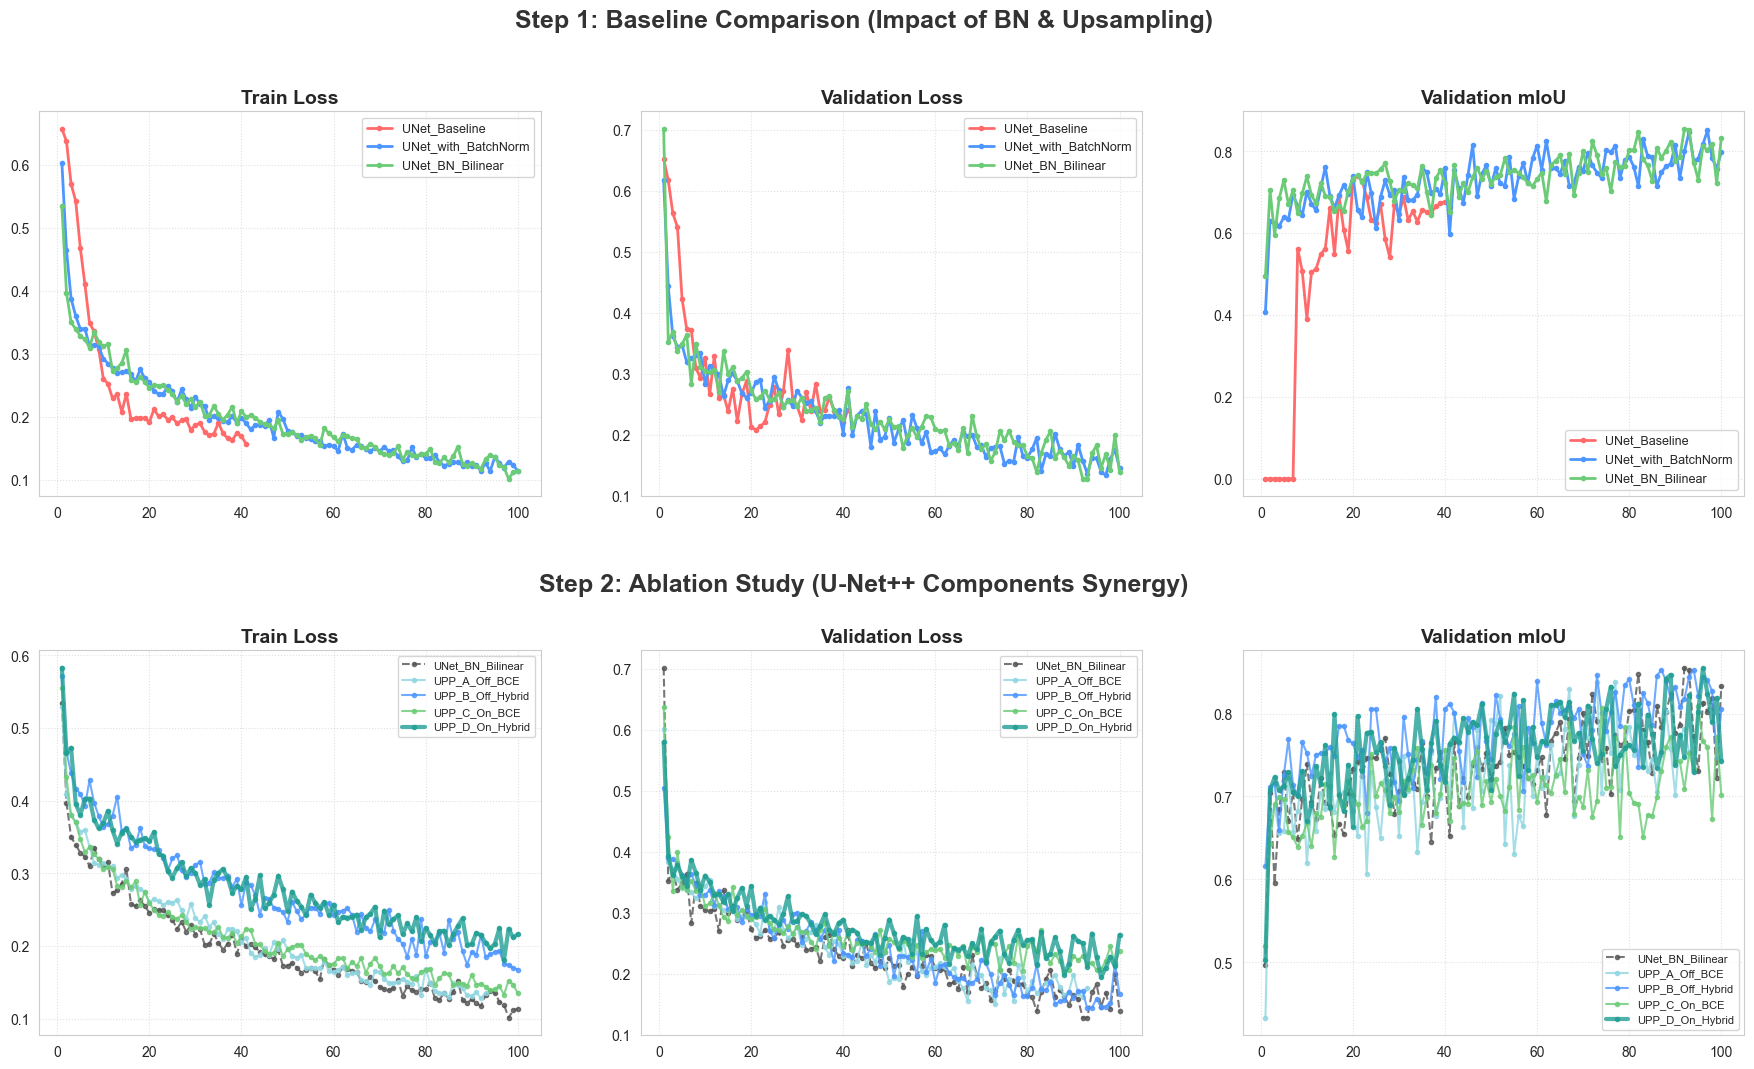

In [45]:
import matplotlib.pyplot as plt

# 1. 그래프 구성 설정
# 상단에 그릴 모델 키값 (histories 딕셔너리의 키와 일치해야 함)
baseline_keys = ["UNet_Baseline", "UNet_with_BatchNorm", "UNet_BN_Bilinear"]
# 하단에 그릴 모델 키값
ablation_keys = ["UNet_BN_Bilinear", "UPP_A_Off_BCE", "UPP_B_Off_Hybrid", "UPP_C_On_BCE", "UPP_D_On_Hybrid"]

# 시각화 지표 및 색상 설정
metrics = [('train_loss', 'Train Loss'), ('val_loss', 'Validation Loss'), ('val_miou', 'Validation mIoU')]
c1 = ['#FF6B6B', '#4D96FF', '#6BCB77']
c2 = ['#555555', '#8FD6E1', '#4D96FF', '#6BCB77', '#219F94']

# 2. 통합 시각화 시작 (2행 3열)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

# --- 상단 (Row 0): 베이스라인 3종 비교 ---
fig.text(0.5, 0.95, "Step 1: Baseline Comparison (Impact of BN & Upsampling)", 
         ha='center', fontsize=18, fontweight='bold', color='#333333')

for j, (col_name, title) in enumerate(metrics):
    ax = axes[0, j]
    for key, color in zip(baseline_keys, c1):
        if key in histories:
            df = histories[key]
            ax.plot(df['epoch'], df[col_name], label=key, marker='o', markersize=3, linewidth=2, color=color)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=9)

# --- 하단 (Row 1): 아블레이션 스터디 5종 비교 ---
fig.text(0.5, 0.48, "Step 2: Ablation Study (U-Net++ Components Synergy)", 
         ha='center', fontsize=18, fontweight='bold', color='#333333')

for j, (col_name, title) in enumerate(metrics):
    ax = axes[1, j]
    for key, color in zip(ablation_keys, c2):
        if key in histories:
            df = histories[key]
            # 베이스라인은 점선으로, 최종 모델(Case D)은 굵게 표시
            ls = '--' if "Bilinear" in key else '-'
            lw = 3 if "Hybrid" in key and "On" in key else 1.5
            ax.plot(df['epoch'], df[col_name], label=key, marker='o', markersize=3, 
                    linewidth=lw, linestyle=ls, color=color, alpha=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=8)

plt.show()


### 5.1.1 기초 학습 궤적(Raw Trajectory) 분석

위 그래프는 100 Epoch 동안 기록된 원본 학습 로그(Train Loss, Validation Loss, Validation mIoU)입니다. 본 시각화를 통해 각 모델의 학습 수렴 상태와 과적합 여부를 1차적으로 진단합니다.

*   **mIoU 지표의 높은 변동성 (Volatility)**
    *   우측의 Validation mIoU 그래프를 보면, 모든 모델이 학습이 진행됨에 따라 우상향하는 정상적인 형태를 띠고 있습니다. 
    *   그러나 배치 사이즈의 한계 및 데이터셋의 특성으로 인해 에폭(Epoch) 간의 점수 진폭(Jitter)이 매우 커서 모델 간의 미세한 성능 우위를 판별하기 어렵습니다. 따라서 본 섹션에서는 Loss 추이 분석에 집중하고, mIoU의 정밀한 성능 추세는 다음 섹션의 '스무딩(Smoothing) 분석'으로 이관합니다.

*   **Hybrid Loss 적용 모델(Case B, D)의 Train Loss 스케일 차이**
    *   하단 좌측의 Train Loss 그래프에서 `UPP_B`와 `UPP_D` 모델이 안정적으로 하향 수렴하고 있음에도 불구하고, 타 모델 대비 절대적인 로스 수치가 높게 형성되는 것을 확인할 수 있습니다.
    *   이는 해당 모델들이 BCE Loss에 Dice Loss가 추가로 합산된 형태의 **Hybrid Loss**를 사용하기 때문입니다. 페널티 항이 늘어남에 따라 자연스럽게 로스의 절댓값이 커진 현상일 뿐, 학습 효율이 저하된 것은 아닙니다.

*   **Deep Supervision 적용 모델(Case C, D)의 Validation Loss 요동 현상**
    *   하단 중앙의 Validation Loss 그래프를 보면, 다중 스케일 지도(Deep Supervision)가 켜진 `UPP_C`와 `UPP_D` 모델의 그래프가 후반부로 갈수록 상하로 톱니처럼 심하게 요동치는 양상을 보입니다.
    *   이는 평가 시 최종 디코더 층의 결과뿐만 아니라, 수용 영역(Receptive Field)이 좁은 얕은 디코더 층의 결과물 3개까지 모두 합산하여 평균 로스를 산출하기 때문입니다. 학습이 후반부에 접어들수록 시야가 좁은 얕은 층들은 처음 보는 검증 데이터(Validation Set)의 패턴 변화에 매우 민감하게 반응하여 예측 오차가 발생하며, 이들의 점수가 평균에 합산되면서 나타나는 구조적인 노이즈(Artifact) 현상으로 해석할 수 있습니다.


### 5.1.2 아키텍처와 손실 함수의 상호작용 분석 (Case B vs Case C)

학습 궤적과 최종 성능 지표를 교차 분석한 결과, 모델의 구조 변화와 손실 함수의 결합 방식에 따른 뚜렷한 상호작용을 확인하였습니다.

*   **Case B (Hybrid ON, DS OFF): 높은 Train Loss와 상반된 높은 검증 성능**
    *   **현상**: Train Loss의 절댓값은 타 모델 대비 높게 형성되나, Validation Loss는 안정적으로 유지되며 검증 데이터 기준 mIoU(약 0.852)가 높게 측정되었습니다.
    *   **분석**: Hybrid Loss(BCE+Dice)는 픽셀 단위 오차 외에 전체적인 형태 불일치에도 페널티를 부여하므로 훈련 중 산출되는 Loss의 수치가 자연스럽게 높아집니다. 그러나 이 추가적인 제약 조건이 모델로 하여금 객체의 전체적인 구조를 학습하도록 유도하여, 미학습 검증 데이터에 대한 일반화(Generalization) 성능 향상에 기여한 것으로 판단됩니다.

*   **Case C (Hybrid OFF, DS ON): 빠른 훈련 수렴과 상반된 검증 성능 저하**
    *   **현상**: Train Loss는 실험군 중 가장 빠르게 수렴하나, Validation Loss의 평균치가 높게 형성되고 최종 mIoU(약 0.809)가 가장 낮게 측정되었습니다.
    *   **분석**: 다중 스케일 지도(Deep Supervision)가 적용된 상태에서 단일 BCE Loss만 사용할 경우, 수용 영역(Receptive Field)이 좁은 얕은 디코더 층들까지 픽셀 단위의 정답 예측에 과적합(Overfitting)될 위험이 있습니다. 전체 형태를 보정하는 Dice Loss의 부재로 인해 국소적 특징에만 최적화되어, 검증 단계에서 성능 저하를 초래한 것으로 보입니다.

*   **소결론: Case D 설계의 타당성**
    *   본 결과는 다중 스케일 지도를 통한 구조적 개선(Deep Supervision)이 안정적인 성능 향상으로 이어지기 위해서는, 모델이 전체적인 형태 정보를 학습할 수 있도록 제어하는 적절한 손실 함수(Hybrid Loss)의 결합이 필수적임을 시사합니다. 이는 두 기법을 동시에 적용한 Case D의 실험적 당위성을 뒷받침합니다.


### 5.2 검증 성능 추세 및 최고점 분석 (Performance Trend & Peak Analysis)

기초 그래프에서 관찰된 지표의 변동성(Jitter)을 배제하고, 모델의 근본적인 성능 개선 궤적과 최종 달성 점수를 명확히 비교하기 위해 3가지 심층 시각화를 진행합니다.

1.  **Savitzky-Golay Smoothed Trend (상단 꺾은선 그래프)**
    *   **목적**: 검증 데이터(Validation)에서 기록된 mIoU의 원본 로그에 사비츠키-골레이 필터를 적용하여 노이즈를 제거합니다. 
    *   **분석 포인트**: 지수 이동 평균(EMA)과 달리 지연(Lag) 현상 없이 최고점(Peak)을 보존하므로, 각 모델이 어느 에폭(Epoch) 부근에서 안정화되는지, 그리고 하이브리드 로스(Hybrid Loss)가 성능 궤적에 어떤 이점을 주는지 직관적으로 관찰할 수 있습니다.

2.  **Best Validation mIoU vs Actual Test mIoU (하단 바 차트 비교)**
    *   **목적**: 학습 과정 중 기록된 최고 점수(왼쪽)와, 별도로 분리된 테스트 셋 30장에 대해 엄격하게 전수 조사한 평균 점수(오른쪽)를 나란히 비교합니다.
    *   **분석 포인트**: 학습 중 우연히 도달한 높은 점수가 실제 추론 환경에서도 유지되는지(일반화 성능 검증), 그리고 아키텍처 개선(Deep Supervision)과 손실 함수(Hybrid Loss)의 결합(Case D)이 성능의 상한선(Ceiling)을 얼마나 끌어올렸는지 수치적으로 증명합니다.


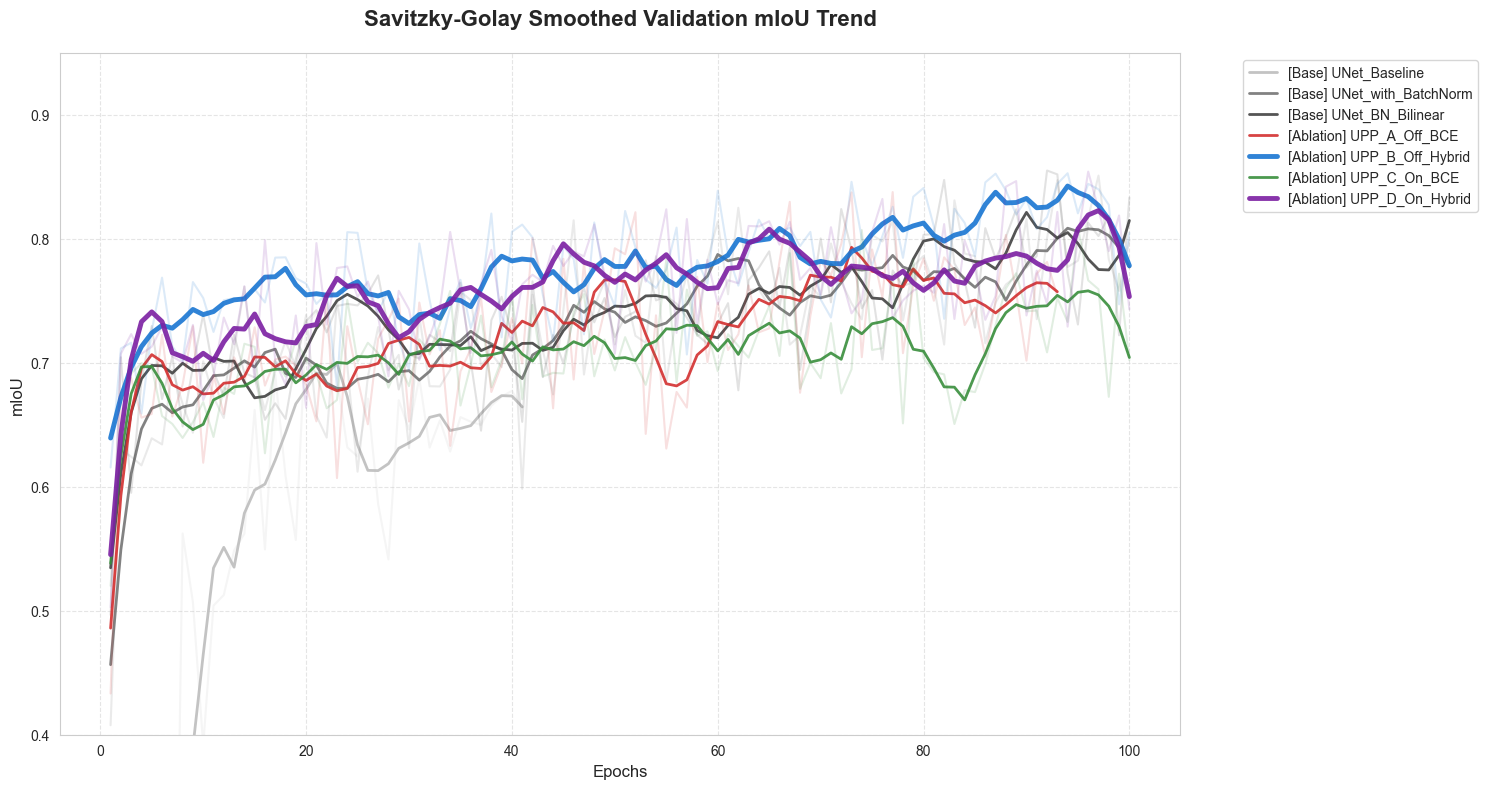

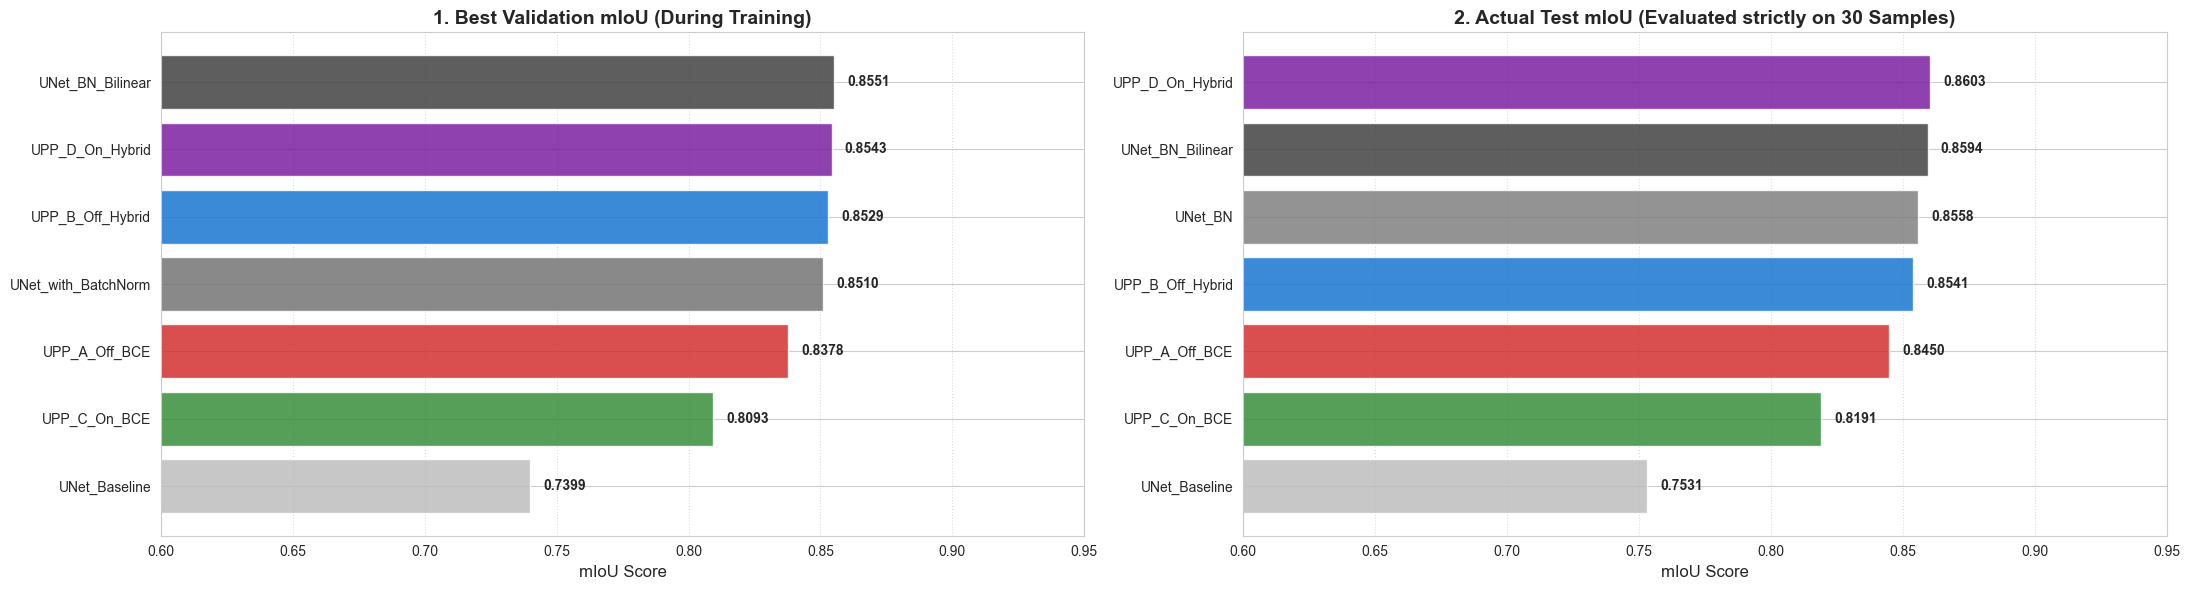

In [52]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def smooth_curve_savgol(points, window_length=15, polyorder=3):
    """
    사비츠키-골레이 필터 적용 함수
    """
    if len(points) < window_length:
        window_length = len(points) if len(points) % 2 != 0 else len(points) - 1
        
    if window_length <= polyorder: 
        return points
        
    return savgol_filter(points, window_length, polyorder)

# 🌟 전역 색상 매핑 딕셔너리 (베이스라인: 무채색 / 아블레이션: 뚜렷한 진한 원색 계열)
model_colors = {
    # 1. Baseline 그룹 (무채색 계열)
    "UNet_Baseline": "#BDBDBD",       # Light Gray
    "UNet_with_BatchNorm": "#757575", # Medium Gray
    "UNet_BN_Bilinear": "#424242",    # Dark Gray
    
    # 2. Ablation 그룹 (가독성 높은 뚜렷하고 진한 색상)
    "UPP_A_Off_BCE": "#D32F2F",       # Deep Red (진한 빨강)
    "UPP_B_Off_Hybrid": "#1976D2",    # Deep Blue (진한 파랑)
    "UPP_C_On_BCE": "#388E3C",        # Deep Green (진한 초록)
    "UPP_D_On_Hybrid": "#7B1FA2"      # Deep Purple (진한 보라)
}

# --- 1. 사비츠키-골레이 스무딩 그래프 ---
plt.figure(figsize=(15, 8))
plt.title("Savitzky-Golay Smoothed Validation mIoU Trend", fontsize=16, fontweight='bold', pad=20)

final_scores = []

for name, df in histories.items():
    if df.empty: continue
    
    epochs = df['epoch']
    miou = df['val_miou']
    
    # 최고 점수 기록 (학습 중 Val mIoU)
    final_scores.append({'name': name, 'best_miou': miou.max()})
    
    # 사비츠키-골레이 필터 적용
    smoothed_miou = smooth_curve_savgol(miou, window_length=11, polyorder=3)
    
    # 고유 색상 매핑 적용
    color = model_colors.get(name, 'gray')
    
    # 하이브리드 로스를 쓴 모델(B, D)은 선을 조금 더 굵게 강조
    linewidth = 3.5 if "Hybrid" in name else 2.0
    label = f"[Ablation] {name}" if "UPP" in name else f"[Base] {name}"
        
    plt.plot(epochs, miou, alpha=0.15, color=color) # 원본 데이터 (투명도 조절)
    plt.plot(epochs, smoothed_miou, label=label, linewidth=linewidth, alpha=0.9, color=color)

plt.xlabel("Epochs", fontsize=12)
plt.ylabel("mIoU", fontsize=12)
plt.ylim(0.4, 0.95)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


# --- 2. [비교 시각화] 학습 중 Best Val mIoU vs 실제 전수 조사 Test mIoU ---
fig, axes = plt.subplots(1, 2, figsize=(22, 6))

# (왼쪽) 학습 중 Best Val mIoU 바 차트
final_df = pd.DataFrame(final_scores).sort_values(by='best_miou')
colors_val = [model_colors.get(n, 'gray') for n in final_df['name']]
bars_val = axes[0].barh(final_df['name'], final_df['best_miou'], color=colors_val, alpha=0.85)

axes[0].set_title("1. Best Validation mIoU (During Training)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("mIoU Score", fontsize=12)
axes[0].set_xlim(0.6, 0.95)
axes[0].grid(axis='x', linestyle=':', alpha=0.7)

for bar in bars_val:
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
                 f'{bar.get_width():.4f}', va='center', fontweight='bold')

# (오른쪽) 실제 Test 셋 전수 조사 mIoU 평균 바 차트
test_scores = []
for name, data in results.items():
    test_scores.append({
        'name': name, 
        'test_miou': np.mean(data['ious']), 
        'color': model_colors.get(name, 'gray') 
    })

test_df = pd.DataFrame(test_scores).sort_values(by='test_miou')
bars_test = axes[1].barh(test_df['name'], test_df['test_miou'], color=test_df['color'], alpha=0.85)

axes[1].set_title("2. Actual Test mIoU (Evaluated strictly on 30 Samples)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("mIoU Score", fontsize=12)
axes[1].set_xlim(0.6, 0.95)
axes[1].grid(axis='x', linestyle=':', alpha=0.7)

for bar in bars_test:
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
                 f'{bar.get_width():.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 5.2.1 추세와 최종 성능의 교차 분석 (Trend vs Actual Performance)

스무딩 궤적(꺾은선)과 실제 전수 조사 결과(우측 바 차트)를 교차로 비교하면, 직관적인 예상과 다른 흥미롭고 중요한 시사점을 도출할 수 있습니다.

*   **Case B(파란색)의 함정: 안정성(Stability)과 최고점(Peak)의 괴리**
    *   **현상**: 스무딩 처리된 추세선 그래프에서는 Case B가 가장 높은 궤적을 그리며 압도적으로 우수한 것처럼 보이나, 실제 테스트 셋 전수 조사에서는 4위(0.8541)에 머물렀습니다.
    *   **분석**: 꺾은선 그래프는 에폭 간의 '평균적인 유지력'을 보여줍니다. Case B는 학습 과정에서 기복 없이 매우 안정적인 방어력을 보였으나, 성능의 상한선(Ceiling) 자체가 돌파되지 못한 것입니다. 반면, 다중 스케일 지도(DS)가 켜진 Case D(보라색)는 학습 중 중간 출력물들이 섞이며 노이즈(상하 요동)가 발생해 추세선상으로는 튀어 보였지만, 이 구조적 노이즈가 강한 정규화(Regularization)로 작용하여 최종 테스트 환경에서는 한계점을 뚫고 1위(0.8603)를 달성했습니다.

*   **통제 대조군(`UNet_BN_Bilinear`, 짙은 회색)의 성능 분석**
    *   **현상**: 베이스라인에 배치 정규화(BN)와 Bilinear 업샘플링을 적용한 대조군이 테스트 결과 2위(0.8594)로 높은 수치를 기록했습니다.
    *   **분석**: 이는 기본 U-Net(0.7531) 대비 발생한 큰 폭의 성능 향상이 아키텍처의 고도화보다는, 각 계층으로 전달되는 데이터 분포의 불안정성(Internal Covariate Shift) 해소와 업샘플링 과정의 아티팩트 보완(Bilinear)에 상당 부분 기인함을 시사합니다. 적절한 통제 대조군 설정이 없었다면 이 거대한 성능 향상분을 온전히 U-Net++의 기여로 오해석할 여지가 있었음을 확인했습니다.


*   **소결론**
    *   기본기를 극한으로 다져놓은 강력한 대조군을 상대로도 유의미한 초과 성능(Over-performance)을 입증해 낸 것은, U-Net++ 구조에 Hybrid Loss를 결합한 Case D가 유일합니다. 이는 모델의 구조적 복잡도 증가가 적절한 손실 함수 가이드라인과 만났을 때 비로소 진정한 시너지로 완성됨을 증명합니다.


### 5.3 개별 샘플 강건성 분석 (Sample-level Robustness)

앞선 전수 조사(바 차트) 결과에서는 통제 대조군(`UNet_BN_Bilinear`)과 최종 아블레이션 모델(Case D) 간의 평균 mIoU 차이가 크지 않음을 확인했습니다. 평균 점수로 인해 희석될 수 있는 모델 간의 실질적인 성능 격차를 규명하기 위해, 30장의 테스트 데이터 각각에 대한 강건성(Robustness) 분석을 진행합니다.

대부분의 데이터가 상위권에 밀집되어 모델 간 우열을 가리기 힘든 현상을 해소하고자, **y축을 비선형적(0.7 기준 상단 확대, 하단 압축)으로 변환**하여 모델 간의 미세한 분할 정밀도 차이를 가시화하였습니다.

*   **Step 1 (베이스라인 비교)**: 배치 정규화(BN)가 기본 U-Net에서 발생하는 치명적인 예측 실패(IoU 0.2 이하의 최악의 케이스)를 어느 수준까지 방어해내는지 확인합니다.
*   **Step 2 (아블레이션 심층 비교)**: 강력한 통제 대조군을 상대로, U-Net++ 구조(Case D)가 가장 어려운 샘플(최악의 조건)들의 하한선(Floor)을 실질적으로 얼마나 끌어올렸는지 검증하여 아키텍처의 강건성을 평가합니다.


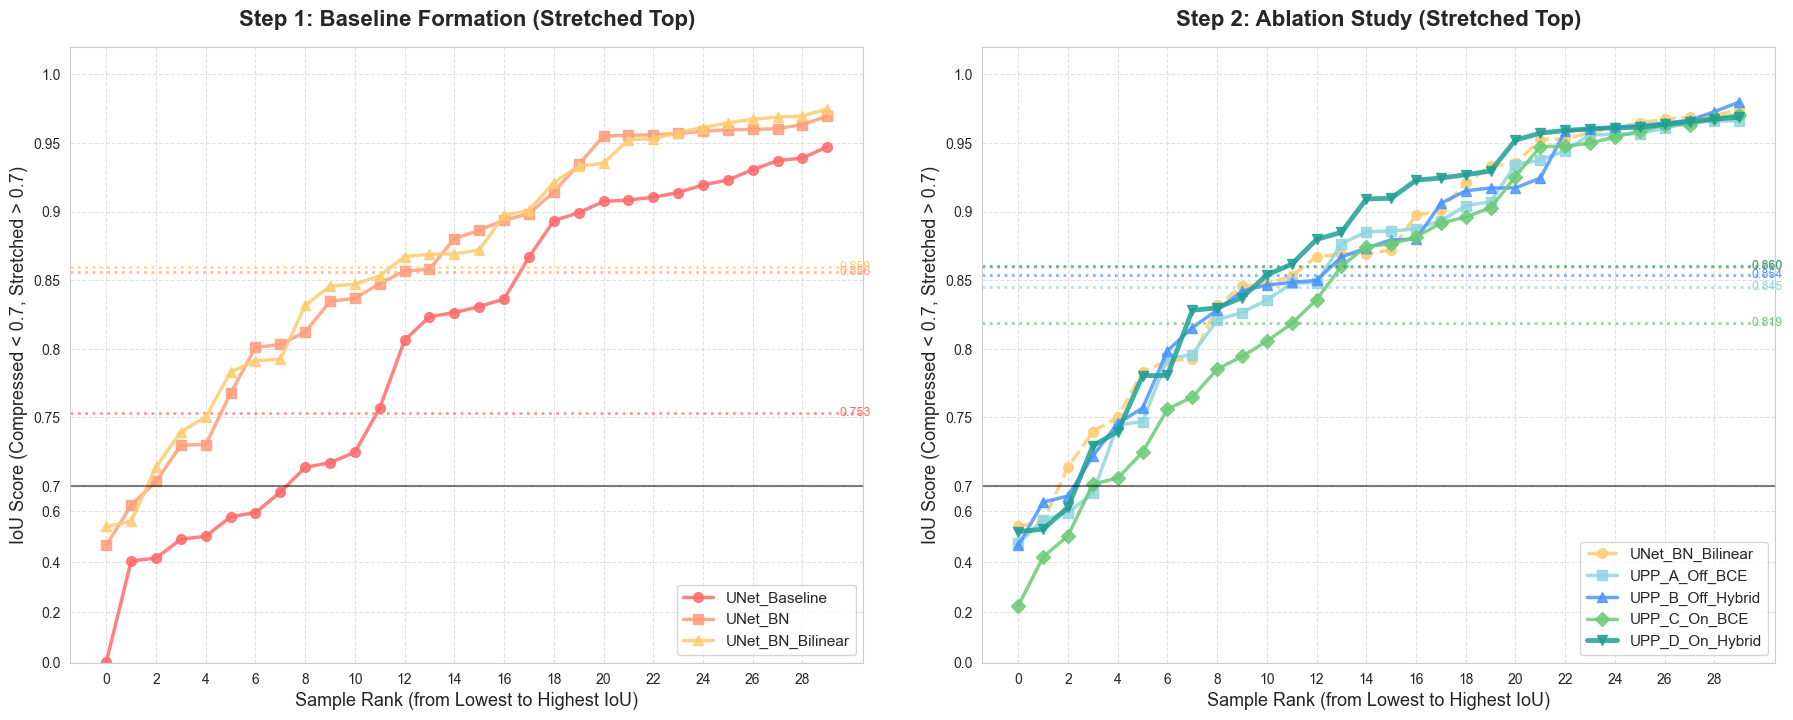

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 모델 그룹 정의
group1_keys = ["UNet_Baseline", "UNet_BN", "UNet_BN_Bilinear"]
group2_keys = ["UNet_BN_Bilinear", "UPP_A_Off_BCE", "UPP_B_Off_Hybrid", "UPP_C_On_BCE", "UPP_D_On_Hybrid"]

markers = ['o', 's', '^', 'D', 'v']
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
plt.subplots_adjust(wspace=0.15)

# 🌟 y축 스케일 왜곡(변환) 함수 정의
# 0.0 ~ 0.7 구간은 전체 y축의 30%만 차지하도록 압축
# 0.7 ~ 1.0 구간은 전체 y축의 70%를 차지하도록 확장
def forward(x):
    return np.piecewise(x, [x < 0.7, x >= 0.7], 
                        [lambda x: x * (0.3/0.7), lambda x: 0.3 + (x - 0.7) * (0.7/0.3)])

def inverse(x):
    return np.piecewise(x, [x < 0.3, x >= 0.3], 
                        [lambda x: x * (0.7/0.3), lambda x: 0.7 + (x - 0.3) * (0.3/0.7)])

# 공통 그래프 그리기 함수
def plot_sorted_ious(ax, keys, title):
    for i, key in enumerate(keys):
        if key not in results: continue
        
        data = results[key]
        sorted_ious = np.sort(data["ious"])
        indices = np.arange(len(sorted_ious))
        
        ls = '--' if "Bilinear" in key and len(keys) > 3 else '-'
        lw = 3.5 if "UPP_D" in key else 2.5
        
        # 선과 점 그리기
        ax.plot(indices, sorted_ious, label=key, marker=markers[i], markersize=7, 
                linewidth=lw, linestyle=ls, color=data["color"], alpha=0.85)
        
        # 🌟 각 모델의 평균 mIoU 가로 점선 추가
        mean_iou = np.mean(sorted_ious)
        ax.axhline(mean_iou, color=data["color"], linestyle=':', linewidth=2, alpha=0.7)
        # 평균선 옆에 살짝 텍스트로 값 적어주기 (선택 사항, 깔끔함을 위해 생략 가능하나 유용함)
        ax.text(29.5, mean_iou, f"{mean_iou:.3f}", color=data["color"], fontsize=9, va='center')
        
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Sample Rank (from Lowest to Highest IoU)", fontsize=13)
    ax.set_ylabel("IoU Score (Compressed < 0.7, Stretched > 0.7)", fontsize=13)
    ax.set_xticks(np.arange(0, 30, 2))
    
    # 🌟 y축 커스텀 스케일 적용
    ax.set_yscale('function', functions=(forward, inverse))
    
    # y축 눈금(Ticks)을 우리가 원하는 대로 수동 지정
    y_ticks = [0.0, 0.2, 0.4, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(t) for t in y_ticks])
    
    ax.set_ylim(0, 1.02)
    ax.grid(True, which='major', linestyle='--', alpha=0.6)
    
    # 0.7 기준선 굵게 표시하여 '여기서부터 확대됨'을 알림
    ax.axhline(0.7, color='black', linewidth=1.5, alpha=0.5)
    
    ax.legend(fontsize=11, loc='lower right')

# --- 1. 첫 번째 그래프 (왼쪽): 베이스라인 3종 ---
plot_sorted_ious(axes[0], group1_keys, "Step 1: Baseline Formation (Stretched Top)")

# --- 2. 두 번째 그래프 (오른쪽): 아블레이션 5종 ---
plot_sorted_ious(axes[1], group2_keys, "Step 2: Ablation Study (Stretched Top)")

plt.show()


### 5.3.1 산점도 분포 기반 강건성 분석 결과

비선형 스케일이 적용된 개별 샘플 정렬 그래프를 분석한 결과, 평균 mIoU 점수 이면에 숨겨진 모델별 강건성(Robustness)의 실질적인 차이를 확인할 수 있습니다.

*   **Case D(최종 모델)의 실질적 강건성 입증**
    *   **현상**: 극단적인 최악의 케이스(랭크 0~2)에서는 Case D가 대조군보다 미세하게 낮은 수치를 보입니다. 그러나 랭크 6을 기점으로 최상위권에 이르기까지, 테스트 셋의 대다수 구간에서 대조군을 포함한 모든 모델을 일관되게 상회하는 궤적을 그립니다.
    *   **분석**: 이는 Case D가 달성한 평균 mIoU 1위(0.8603)의 성과가 단순히 몇몇 쉬운 샘플에서 높은 점수를 얻었기 때문이 아니라, 대다수의 어려운 조건(중하위권 랭크)에서도 분할 정밀도를 안정적으로 끌어올리는(Floor-raising) 실질적인 강건성을 갖추었음을 입증합니다.

*   **Case C의 전반적인 방어력 붕괴**
    *   **현상**: 평균 점수가 가장 낮았던 Case C는 특정 난이도에 국한되지 않고, 모든 구간(랭크 0~29)에서 일관되게 최하위 궤적을 형성하고 있습니다.
    *   **분석**: 이는 앞서 5.1.2 섹션에서 진단한 바와 같이, 적절한 손실 함수(Hybrid Loss) 없이 Deep Supervision만 강제했을 때 발생하는 과적합 현상이 전체 테스트 셋에 걸쳐 객체 인식 능력을 전반적으로 저하시켰음을 수치적으로 재확인하는 결과입니다.

*   **단일 요소 추가 모델(Case A, B)과 통제 대조군의 한계**
    *   **현상**: 구조만 변경한 Case A와 손실 함수만 변경한 Case B는 강력한 통제 대조군(`UNet_BN_Bilinear`)과 거의 유사하게 얽혀 궤적을 그리며 유의미한 격차를 벌리지 못했습니다.
    *   **분석**: 이는 아키텍처 개선(Nested Skip Connection)이나 손실 함수 변경(Hybrid Loss) 중 하나만을 단독으로 적용하는 것은, 이미 배치 정규화(BN)로 최적화된 대조군의 성능 상한선을 깨기 어렵다는 점을 시사합니다. 두 요소가 결합된 Case D만이 궤적을 이탈하여 우위를 점한 사실이 이를 뒷받침합니다.


### 5.4 정량적 성능 분석 소결 및 향후 과제 (Conclusion & Future Work)

본 아블레이션 스터디의 정량적 평가 지표와 궤적을 종합적으로 분석한 결과, 다음과 같은 핵심 결론을 도출하였습니다.

1.  **배치 정규화(BN)의 압도적 비용 효율성**
    *   전체 실험을 통틀어 가장 극적인 성능 향상을 이끌어낸 요소는 모델 파라미터의 증가량이 극히 미미한 배치 정규화(BN)의 도입이었습니다. 기본 U-Net(0.7531)에 단순히 BN만 추가된 모델(`UNet_BN`, 0.8558) 단계에서 이미 약 0.1(10%p) 이상의 압도적인 성능 수직 상승이 발생했습니다. 
    *   이는 본 데이터셋 환경에서, 아키텍처를 복잡하게 설계하는 것보다 각 네트워크 계층으로 전달되는 데이터 분포의 불안정성(Internal Covariate Shift)을 해결해 주는 기본기가 성능 향상의 가장 핵심적인 병목(Bottleneck)이었음을 명확히 보여줍니다.

2.  **구조와 손실 함수의 비선형적 시너지 (Ablation 결론)**
    *   아블레이션 실험군의 최종 성능은 **Case D > B > A > C** 순으로 나타났습니다.
    *   통제 대조군(Case A)을 기준으로, 형태 제어 손실 함수만 적용한 Case B는 단독으로도 성능 방어력 향상에 기여했습니다. 반면, 다중 스케일 지도만 강제한 Case C는 얕은 층의 과적합을 유발해 오히려 성능을 훼손하는 결과를 낳았습니다.
    *   흥미로운 점은 단독으로는 성능을 저하시켰던 요소(C)가, 적절한 가이드라인(B)과 결합된 **Case D**에 이르러서야 비로소 모든 대조군을 뛰어넘는 최고 성능을 기록했다는 점입니다. 이는 한계 돌파를 위해서는 두 기술 요소가 상호 약점을 보완하는 비선형적 시너지(Synergy)를 이루어야 함을 완벽하게 증명합니다.

**향후 과제 (Future Work)**
학습 과정 분석 중, 특정 모델에 국한되지 않고 7개 모델 전체에서 공통적으로 훈련 후반부 검증 로스(Validation Loss)가 크게 요동치는 진동 현상이 관찰되었습니다. 이는 에폭이 진행됨에 따라 고정된 학습률(Learning Rate 1e-4)이 최적점(Global Minimum) 근처에서의 세밀한 안착을 방해하고 있음을 시사합니다. 따라서 향후 후속 실험에서는 **학습률 스케줄러(Learning Rate Scheduler, 예: Cosine Annealing, ReduceLROnPlateau 등)를 도입하여 후반부 수렴 궤적을 안정화하는 연구**가 수반되어야 할 것입니다.


## 6. 정성적 성능 분석 (Qualitative Analysis)

본 섹션에서는 정량 평가에서 확인된 아키텍처별 성능 차이가 실제 예측 결과물(Mask)에 어떻게 반영되는지 시각적으로 검증합니다. 효율적이고 객관적인 분석을 위해 30장의 테스트 셋 전체를 나열하는 대신, 이미지별 성능 격차를 수치화하여 대표 표본(Representative Sample)을 선별하는 과정을 선행합니다.

### 6.1 심층 분석을 위한 대표 표본 선정 (Representative Sample Selection)

아래의 표는 30장의 테스트 이미지 각각에 대한 7개 모델의 IoU 점수와, 이미지별 모델 간 최대 격차(Max-Min Gap)를 나타냅니다. 본 데이터를 기준으로 아키텍처의 한계와 시너지가 가장 명확하게 관찰되는 4개의 대표 이미지를 선정합니다.


In [64]:
import pandas as pd
import numpy as np

# 1. results 딕셔너리에서 모든 모델(7개)의 IoU 리스트 추출
iou_data = {}
for model_name, data in results.items():
    iou_data[model_name] = data["ious"]

# 2. Pandas DataFrame으로 변환
df_iou = pd.DataFrame(iou_data)
model_columns = list(results.keys())

# 3. 행(Index) 이름을 알기 쉽게 변경 (Image_00 ~ Image_29)
df_iou.index = [f"Image_{str(i).zfill(2)}" for i in range(len(df_iou))]

# 4. 각 이미지별(행별) 분석 열 추가
df_iou['Max_IoU'] = df_iou[model_columns].max(axis=1)
df_iou['Min_IoU'] = df_iou[model_columns].min(axis=1)
df_iou['Mean_IoU'] = df_iou[model_columns].mean(axis=1) # 해당 이미지의 평균 점수 (난이도)
df_iou['Max-Min Gap'] = df_iou['Max_IoU'] - df_iou['Min_IoU']
df_iou['Best_Model'] = df_iou[model_columns].idxmax(axis=1)

# 5. 하단에 모델별 전체 평균(Average) 행 추가
mean_row = df_iou[model_columns + ['Max_IoU', 'Min_IoU', 'Mean_IoU', 'Max-Min Gap']].mean().to_dict()
mean_row['Best_Model'] = "-" # 평균 행의 Best_Model은 비워둠
df_iou.loc['Average_Score'] = mean_row

# 6. CSV 파일로 저장
df_iou.to_csv("test_iou_results_all.csv")
print("✅ 'test_iou_results_all.csv' 파일로 저장되었습니다.")

# 7. 노트북 화면에 예쁘게 출력
# Average_Score 행과 Best_Model 열을 제외한 숫자 부분 포맷팅
format_cols = model_columns + ['Max_IoU', 'Min_IoU', 'Mean_IoU', 'Max-Min Gap']

display(
    df_iou.style
    .format("{:.4f}", subset=format_cols)
    .background_gradient(cmap='RdYlGn', subset=model_columns, axis=1) # 행 안에서 모델 간 비교
)


✅ 'test_iou_results_all.csv' 파일로 저장되었습니다.


,UNet_Baseline,UNet_BN,UNet_BN_Bilinear,UPP_A_Off_BCE,UPP_B_Off_Hybrid,UPP_C_On_BCE,UPP_D_On_Hybrid,Max_IoU,Min_IoU,Mean_IoU,Max-Min Gap,Best_Model
Image_00,0.7569,0.7303,0.7396,0.8482,0.7220,0.7247,0.8538,0.8538,0.7220,0.7679,0.1318,UPP_D_On_Hybrid
Image_01,0.4036,0.7298,0.5612,0.8765,0.8498,0.7059,0.8373,0.8765,0.4036,0.7092,0.4730,UPP_A_Off_BCE
Image_02,0.5013,0.8033,0.7832,0.5950,0.9243,0.8814,0.7806,0.9243,0.5013,0.7527,0.4230,UPP_B_Off_Hybrid
Image_03,0.4149,0.4659,0.5401,0.4732,0.4653,0.5037,0.5292,0.5401,0.4149,0.4846,0.1252,UNet_BN_Bilinear
Image_04,0.8363,0.9343,0.8973,0.9043,0.9171,0.8764,0.9228,0.9343,0.8363,0.8984,0.0980,UNet_BN
Image_05,0.6765,0.8984,0.8719,0.7930,0.7985,0.8358,0.8797,0.8984,0.6765,0.8220,0.2219,UNet_BN
Image_06,0.8264,0.7678,0.7925,0.7470,0.7458,0.7015,0.7397,0.8264,0.7015,0.7601,0.1249,UNet_Baseline
Image_07,0.8991,0.8346,0.8457,0.8873,0.9060,0.8959,0.9268,0.9268,0.8346,0.8851,0.0922,UPP_D_On_Hybrid
Image_08,0.8234,0.8368,0.8471,0.9071,0.8733,0.8916,0.9091,0.9091,0.8234,0.8698,0.0857,UPP_D_On_Hybrid
Image_09,0.8308,0.8579,0.8691,0.8356,0.8464,0.8745,0.8616,0.8745,0.8308,0.8537,0.0437,UPP_C_On_BCE


### 6.2 오버레이 시각화 및 아키텍처 특성 교차 검증

앞선 표(6.1)의 결과를 바탕으로 데이터 분포 측면에서 가장 유의미한 변동성을 보인 4개의 이미지를 선정하였습니다. 선별된 이미지에 대해 기본 모델(Baseline), 대조군(BN_Bilinear), 그리고 핵심 요소가 적용된 3종의 U-Net++ 계열 모델을 시각적으로 비교 분석합니다.

**비교 대상 모델 (5종)**
1. `UNet_Baseline`: 최적화 이전의 기본 아키텍처
2. `UNet_BN_Bilinear`: 배치 정규화(BN)가 적용된 통제 대조군
3. `UPP_B_Off_Hybrid`: 다중 스케일 지도(DS) 없이 Hybrid Loss만 적용된 모델
4. `UPP_C_On_BCE`: Hybrid Loss 없이 Deep Supervision만 적용된 모델
5. `UPP_D_On_Hybrid`: DS와 Hybrid Loss가 모두 적용된 최종 융합 모델

**선정된 4대 핵심 표본 분석 결과**

*   **Image_27 (Baseline Failure 및 BN의 효과)**
    *   **현상**: 베이스라인 모델(IoU 0.0033)이 도로 영역 예측에 완전히 실패한 반면, 대조군(IoU 0.7912)은 정상적인 형태를 출력했습니다.
    *   **분석**: 레이어가 깊어짐에 따라 발생하는 내부 공변량 변화(Internal Covariate Shift)로 인해 계층 간 분산이 무너져 예측값이 소실된 사례입니다. 배치 정규화(BN)의 도입이 모델의 출력 안정성에 미치는 결정적인 영향을 보여줍니다. 추가로, Case C(IoU 0.2263)의 하락은 구조가 복잡해지더라도 손실 함수의 결합이 부적절할 경우 모델이 다시 불안정해질 수 있음을 시사합니다.

*   **Image_02 (Hybrid Loss의 단독 성능 확인)**
    *   **현상**: 대조군(IoU 0.7832)과 최종 모델(IoU 0.7806)의 점수가 상대적으로 저조한 구간에서, Hybrid Loss 단독 적용 모델인 Case B가 가장 높은 점수(IoU 0.9243)를 기록했습니다.
    *   **분석**: 픽셀 단위의 오차(BCE)뿐만 아니라 객체의 전반적인 형태(Dice)를 동시에 학습하도록 제어하는 Hybrid Loss가, 특정 기하학적 조건에서 아키텍처의 복잡성을 상회하는 높은 분할 정밀도를 제공함을 보여줍니다.

*   **Image_19 (아키텍처 요소 간의 시너지 증명)**
    *   **현상**: Case C(IoU 0.7852)가 대조군(IoU 0.9008) 대비 성능 하락을 보였으나, Hybrid Loss가 결합된 최종 모델 Case D(IoU 0.9295)에서는 전체 최고 성능으로 반등했습니다.
    *   **분석**: 다중 스케일 지도(DS) 단독 적용 시 얕은 레이어의 국소적 특징(Local Feature)에 과적합되는 한계(Case C)가 발생합니다. 그러나 구조적 결속력을 강제하는 Hybrid Loss와 결합할 경우(Case D), 이러한 단점이 억제되고 다양한 스케일의 특징이 유효하게 융합되며 최적의 시너지를 창출함을 증명합니다.

*   **Image_24 (모델 복잡성에 따른 과적합 역설)**
    *   **현상**: 베이스라인 및 대조군(IoU 0.91~0.92)이 우수한 성능을 보인 평이한 환경에서, 매개변수가 많은 U-Net++ 계열 모델들(Case B: 0.6367, Case D: 0.7295)의 성능이 오히려 크게 저하되었습니다.
    *   **분석**: 모델의 수용력(Capacity)이 지나치게 클 경우, 데이터셋의 특정 단순 패턴에 과적합(Over-parameterization)되어 일반화 성능이 하락할 수 있음을 나타냅니다. 이는 본 모델의 한계점과 향후 파라미터 경량화 연구의 필요성을 뒷받침하는 사례입니다.


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19784\820115106.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vis_models["UNet_Baseline"].load_state_dict(torc

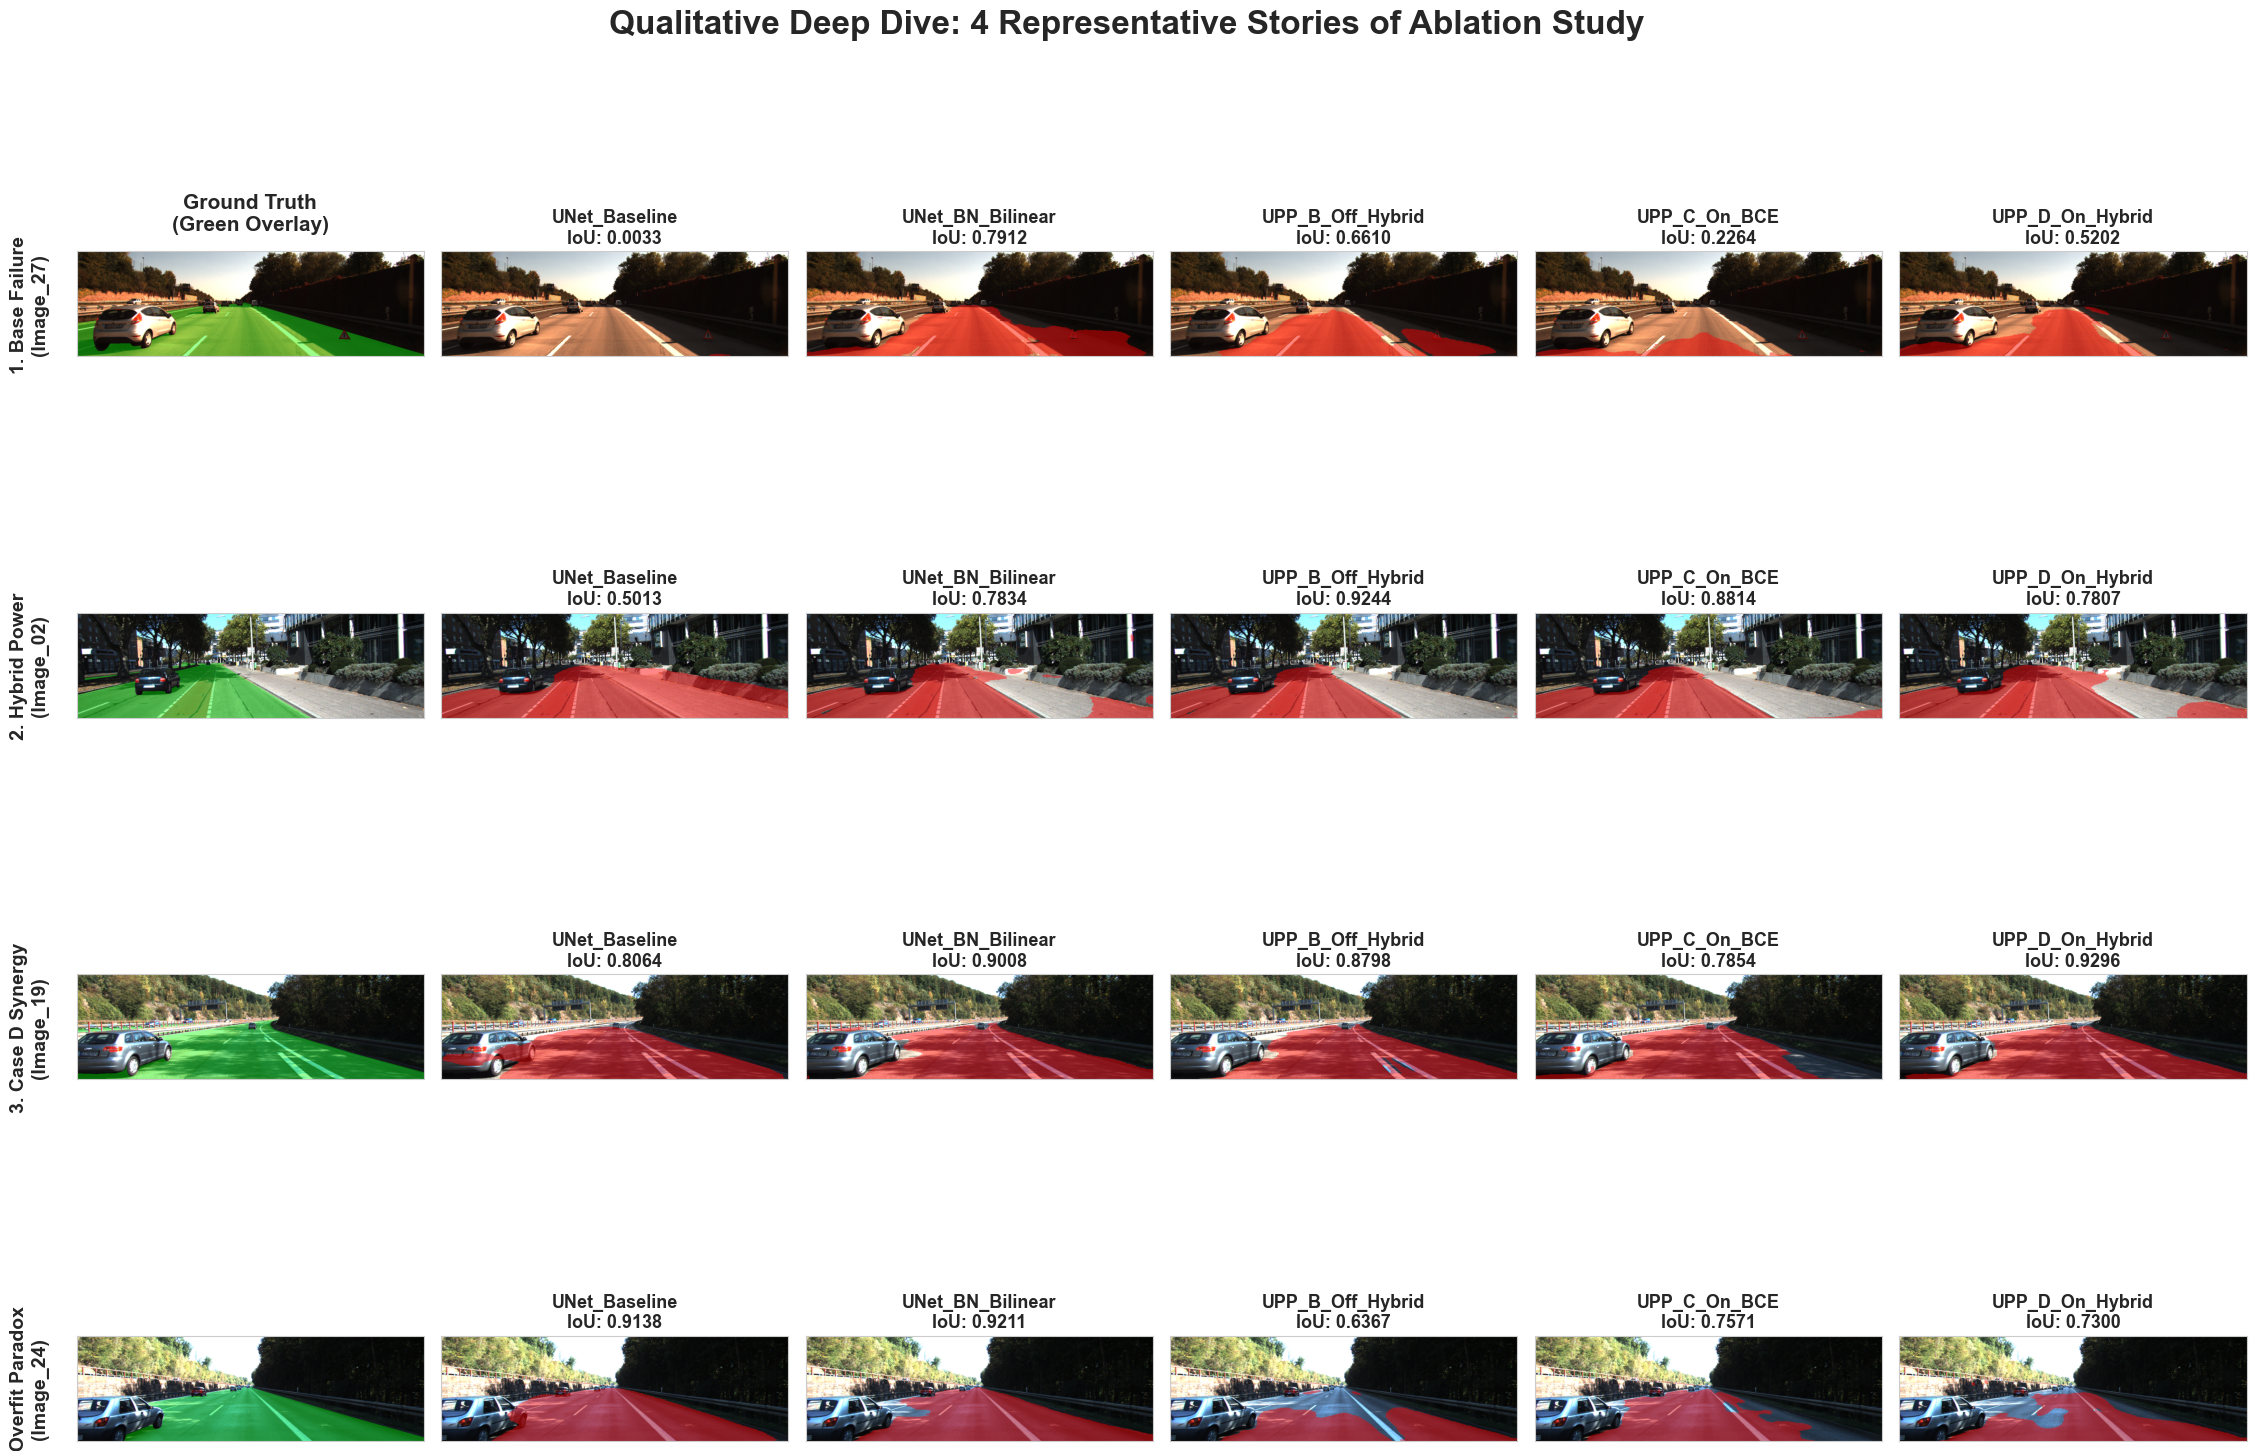

In [63]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. 시각화를 위한 5종 핵심 모델 로드 (Case B 추가)
vis_models = {
    "UNet_Baseline": UNet(input_channels=3, output_channels=1).to(device),
    "UNet_BN_Bilinear": UNet_BN_Bilinear(input_channels=3, output_channels=1).to(device),
    "UPP_B_Off_Hybrid": UNetPlusPlus(input_channels=3, output_channels=1, deep_supervision=False).to(device),
    "UPP_C_On_BCE": UNetPlusPlus(input_channels=3, output_channels=1, deep_supervision=True).to(device),
    "UPP_D_On_Hybrid": UNetPlusPlus(input_channels=3, output_channels=1, deep_supervision=True).to(device)
}

vis_models["UNet_Baseline"].load_state_dict(torch.load("models/UNet_Baseline.pt", map_location=device))
vis_models["UNet_BN_Bilinear"].load_state_dict(torch.load("models/UNet_BN_Bilinear.pt", map_location=device))
vis_models["UPP_B_Off_Hybrid"].load_state_dict(torch.load("models/UPP_B_Off_Hybrid.pt", map_location=device))
vis_models["UPP_C_On_BCE"].load_state_dict(torch.load("models/UPP_C_On_BCE.pt", map_location=device))
vis_models["UPP_D_On_Hybrid"].load_state_dict(torch.load("models/UPP_D_On_Hybrid.pt", map_location=device))

for m in vis_models.values():
    m.eval()

# 2. 정성 분석용 핵심 타겟 인덱스 고정 (데이터프레임 기-승-전-결 기반)
target_indices = [27, 2, 19, 24]
row_titles = [
    "1. Base Failure\n(Image_27)", 
    "2. Hybrid Power\n(Image_02)", 
    "3. Case D Synergy\n(Image_19)", 
    "4. Overfit Paradox\n(Image_24)"
]

# 3. 유틸리티 함수들 (원본 해상도 및 색감 유지 로직 적용)
def predict_mask(model, image_tensor):
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0).to(device))
        if isinstance(output, list): output = output[-1]
        mask = (output > 0.5).float().cpu().squeeze().numpy()
    return mask

def overlay_mask_raw(img_path, mask_array, color="red"):
    img = Image.open(img_path)
    background = img.convert('RGBA')
    # 예측된 224x224 마스크를 원본 고화질 해상도로 부드럽게 복원
    mask_img = Image.fromarray((mask_array * 255).astype(np.uint8)).resize(img.size, resample=Image.NEAREST)
    
    overlay = Image.new("RGBA", background.size, (0, 0, 0, 0))
    if color == "red": overlay.paste((255, 0, 0, 120), (0, 0), mask_img)
    else: overlay.paste((0, 255, 0, 100), (0, 0), mask_img)
        
    return Image.alpha_composite(background, overlay)

def calc_iou(pred, gt):
    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection
    if union == 0: return 1.0
    return intersection / union

# 4. 고해상도 플롯 그리기 (4행 6열 셋업)
fig, axes = plt.subplots(4, 6, figsize=(28, 18))
plt.subplots_adjust(wspace=0.05, hspace=0.2)

test_dataset = test_loader.dataset

for row, idx in enumerate(target_indices):
    image, tensor_mask = test_dataset[idx] 
    img_path, label_path = test_dataset.data[idx]
    
    # [1열] 정답 (Ground Truth)
    label_img = np.array(Image.open(label_path))
    gt_array_raw = (label_img == 7).astype(np.uint8)
    
    gt_blended = overlay_mask_raw(img_path, gt_array_raw, color="green")
    axes[row, 0].imshow(gt_blended)
    if row == 0: axes[row, 0].set_title("Ground Truth\n(Green Overlay)", fontsize=15, fontweight='bold', pad=15)
    axes[row, 0].set_ylabel(row_titles[row], fontsize=14, fontweight='bold', labelpad=20)
    
    # [2~6열] 5종 모델별 예측 및 IoU 계산
    col = 1
    for name, model in vis_models.items():
        pred_array = predict_mask(model, image)
        pred_blended = overlay_mask_raw(img_path, pred_array, color="red")
        
        # IoU 계산용 정답 텐서 언패킹
        gt_tensor_np = tensor_mask.squeeze().numpy()
        single_iou = calc_iou(pred_array, gt_tensor_np)
        
        axes[row, col].imshow(pred_blended)
        axes[row, col].set_title(f"{name}\nIoU: {single_iou:.4f}", fontsize=13, fontweight='bold')
        col += 1

# 축 지우기
for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Qualitative Deep Dive: 4 Representative Stories of Ablation Study", fontsize=24, fontweight='bold', y=0.96)
plt.show()


### 6.2 오버레이 시각화 및 아키텍처 특성 교차 검증

앞선 6.1의 결과를 바탕으로 선정된 4개의 이미지에 대해, 예측 마스크(빨간색)와 실제 정답(초록색)을 원본 이미지에 오버레이하여 비교 분석합니다. 

**비교 대상 모델 (5종)**
1. `UNet_Baseline`: 최적화 이전의 기본 아키텍처
2. `UNet_BN_Bilinear`: 배치 정규화(BN)가 적용된 통제 대조군
3. `UPP_B_Off_Hybrid`: 다중 스케일 지도(DS) 없이 Hybrid Loss만 적용된 모델
4. `UPP_C_On_BCE`: Hybrid Loss 없이 Deep Supervision만 적용된 모델
5. `UPP_D_On_Hybrid`: DS와 Hybrid Loss가 모두 적용된 최종 융합 모델

**선정된 4대 핵심 표본 시각적 분석 결과**

*   **Image_27 (Baseline Failure 및 BN의 효과)**
    *   **시각적 현상**: 역광 환경에서 베이스라인 모델(IoU 0.0033)은 예측 마스크를 전혀 출력하지 못했습니다. 반면, 대조군(IoU 0.7912)은 도로 영역 대부분을 정상적으로 분할했습니다. Case C(IoU 0.2264)는 화면 하단의 좁은 영역만 부분적으로 예측하는 데 그쳤습니다.
    *   **분석**: 베이스라인의 출력 소실은 내부 공변량 변화(Internal Covariate Shift)에 의한 계층 간 분산 붕괴를 나타냅니다. 대조군의 결과는 배치 정규화(BN)가 모델의 연산 안정성을 보장함을 증명합니다. 또한, Case C의 예측 영역 축소는 손실 함수 설계가 부적절할 경우 아키텍처가 고도화되더라도 예측 성능이 다시 하락할 수 있음을 시사합니다.

*   **Image_02 (Hybrid Loss의 단독 성능 확인)**
    *   **시각적 현상**: 우측 인도와 도로가 맞닿은 구간에서, 베이스라인 및 대조군은 인도 영역을 침범하여 마스크가 넓게 분포했습니다. 반면, Case B(IoU 0.9244)는 우측 경계선을 따라 인도 침범 없이 마스크를 정밀하게 구획했습니다.
    *   **분석**: 이는 Hybrid Loss 내 Dice Loss의 형태 제어 효과를 나타냅니다. 픽셀 단위의 오차(BCE)와 객체의 전체적 구조(Dice)를 동시 학습함으로써, 복잡한 주변 환경에서도 객체의 경계선(Boundary)을 훼손하지 않는 높은 분할 정밀도를 제공함을 증명합니다.

*   **Image_19 (아키텍처 요소 간의 시너지 증명)**
    *   **시각적 현상**: 우측으로 휘어지는 곡선 도로에서 Case C(IoU 0.7854)는 우측 차선 영역을 인식하지 못해 예측 마스크의 폭이 축소되었습니다. 그러나 최종 모델인 Case D(IoU 0.9296)는 누락된 우측 영역을 모두 포함하여 실제 정답(GT)과 일치하는 마스크 폭을 예측했습니다.
    *   **분석**: Case C의 마스크 축소는 다중 스케일 지도(DS) 단독 적용 시 얕은 레이어의 국소적 특징에 과적합되어 수용 영역(Receptive Field)이 제한되는 한계를 보여줍니다. 반면, Case D는 Hybrid Loss의 구조적 제어가 결합되어 이러한 단점이 상쇄되었으며, 다중 스케일 특징이 정상적으로 융합되는 시너지를 증명합니다.

*   **Image_24 (모델 복잡성에 따른 과적합 역설)**
    *   **시각적 현상**: 밝은 조명의 직선 도로에서 베이스라인과 대조군(IoU 0.91~0.92)은 도로 전체를 마스크로 온전히 덮었습니다. 그러나 U-Net++ 계열인 Case B와 Case D(IoU 0.63~0.73)는 예측 마스크 중앙부에 넓은 면적의 누락(Hole) 공간이 발생했습니다.
    *   **분석**: 이는 모델의 수용력(Capacity)이 필요 이상으로 클 경우 나타나는 과적합(Over-parameterization) 현상입니다. 복잡한 아키텍처가 아스팔트의 미세한 색상이나 조명 질감 차이 등 불필요한 세부 특징에 반응하여, 평이한 환경에서 오히려 형태적 일관성을 잃었음을 시사합니다. 향후 파라미터 경량화 및 규제(Regularization) 연구의 필요성을 뒷받침하는 사례입니다.


## 7. 최종 결론 및 향후 과제 (Conclusion & Future Work)

본 아블레이션 스터디의 정량적 평가 지표(mIoU)와 정성적 시각화 결과(예측 마스크 오버레이)를 종합적으로 분석하여 다음과 같은 최종 결론을 도출하였습니다.

### 7.1 핵심 결론 (Key Findings)

1. **배치 정규화(BN)의 압도적 비용 효율성**
   * 전체 실험을 통틀어 가장 극적인 성능 향상을 이끌어낸 요소는 파라미터 증가량이 미미한 배치 정규화(BN)의 도입이었습니다. 기본 U-Net(0.7531)에 BN만 추가된 모델 단계에서 이미 약 0.1(10%p) 이상의 성능 수직 상승이 발생했습니다. 
   * 이는 본 데이터셋 환경에서, 아키텍처를 복잡하게 설계하는 것보다 각 네트워크 계층으로 전달되는 데이터 분포의 불안정성(Internal Covariate Shift)을 해결하는 기본기가 성능 향상의 가장 핵심적인 병목(Bottleneck)이었음을 명확히 보여줍니다.

2. **구조와 손실 함수의 비선형적 시너지 (U-Net++ 아블레이션)**
   * U-Net++ 계열 실험군의 최종 성능은 **Case D(0.8603) > Case B(0.8541) > Case A(0.8450) > Case C(0.8191)** 순으로 나타났습니다.
   * 다중 스케일 지도(DS)만 단독으로 강제한 Case C는 얕은 층의 과적합을 유발해 성능을 크게 훼손했습니다. 반면, 형태 제어 손실 함수(Hybrid Loss)만 적용한 Case B는 단독으로도 준수한 성능 방어력을 보였습니다.
   * 가장 중요한 발견은, 단독으로는 성능을 저하시켰던 요소(C)가 적절한 형태적 가이드라인(B)과 결합된 최종 융합 모델(Case D)에 이르러서야 모든 대조군을 뛰어넘는 최고 성능을 기록했다는 점입니다. 이는 한계 돌파를 위해서는 개별 기술 요소가 상호 약점을 보완하는 비선형적 시너지(Synergy)를 이루어야 함을 완벽히 증명합니다.

3. **모델 복잡성에 따른 과적합 역설 (Overfitting Paradox)**
   * 정성 분석 과정에서, 베이스라인과 대조군이 완벽하게 인식한 평이한 직진 도로 환경을 오히려 파라미터가 많은 U-Net++ 계열 모델들이 오판하여 마스크 중앙부에 거대한 누락(Hole)이 발생하는 현상이 관찰되었습니다. 
   * 이는 모델의 수용력(Capacity)이 지나치게 클 경우 불필요한 미세 질감(아스팔트의 빛 반사 등)에 과민 반응하여 형태적 일관성을 잃는 과적합(Over-parameterization) 현상으로, 복잡한 모델이 무조건적인 정답이 될 수 없음을 명확히 시사합니다.

### 7.2 향후 과제 (Future Work)

1. **학습률 스케줄링(LR Scheduler) 도입을 통한 안정화**
   * 학습 궤적 분석 결과, 특정 모델에 국한되지 않고 7개 모델 전체에서 공통적으로 훈련 후반부 검증 손실(Validation Loss)이 크게 요동치는 진동 현상이 관찰되었습니다. 
   * 이는 에폭이 진행됨에 따라 고정된 학습률(Learning Rate 1e-4)이 최적점(Global Minimum) 근처에서의 세밀한 안착을 방해하고 있음을 시사합니다. 향후 후속 실험에서는 `CosineAnnealingLR` 또는 `ReduceLROnPlateau` 등의 학습률 스케줄러를 도입하여 훈련 후반부의 수렴 궤적을 안정화하는 연구가 수반되어야 합니다.

2. **파라미터 경량화 및 규제(Regularization) 기법 탐구**
   * 앞서 확인된 과적합 역설을 해결하기 위해, 단순한 환경에서의 강건성을 높이는 추가 연구가 필요합니다. Dropout 비율의 재조정, Weight Decay의 추가, 혹은 채널 수를 줄인 경량화된 U-Net++ 구조를 테스트하여 복잡도와 일반화(Generalization) 성능 간의 최적의 타협점(Trade-off)을 찾는 실험을 제안합니다.


## 회고 (Retrospective)

본 프로젝트는 아블레이션 스터디의 신뢰성을 확보하기 위해 랜덤 시드(Random Seed) 고정 및 엄격한 대조군 설정 등 철저히 통제된 실험 환경을 구축하는 데 주력했습니다. 

이러한 실험 환경 통제를 바탕으로 대조군 모델에 배치 정규화(Batch Normalization)를 독립 변인으로 추가하여 분석을 진행할 수 있었습니다. 그 결과, 기본 U-Net과 U-Net++ 간의 극적인 성능 격차가 단순히 아키텍처의 고도화에서 기인한 것이 아니라, 상당 부분 배치 정규화를 통한 내부 공변량 분산 억제 효과에서 비롯되었음을 객관적으로 규명할 수 있었습니다. 

결과적으로, 화려한 최신 기법의 무조건적인 도입보다는 데이터의 정밀한 통제와 기본기(Normalization)의 충실한 구현이 딥러닝 모델 성능 향상의 근간이 됨을 확인한 유의미한 연구였습니다.
